In [1]:
# Global plotting configuration for this notebook
GRAYSCALE = True
FONT_SCALE = 1.2
DPI = 300

# Apply base Matplotlib DPI globally (titles/labels sized per-plot below)
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = DPI
mpl.rcParams['savefig.dpi'] = DPI


In [2]:
# Resolve and expose project root for imports and data paths
import os, sys
from pathlib import Path

def find_project_root(markers=("py_scripts", "examples_audio", "examples_csv")) -> Path:
    current_path = Path.cwd().resolve()
    for parent in [current_path, *current_path.parents]:
        if any((parent / m).is_dir() for m in markers):
            return parent
    raise RuntimeError(f"Could not locate project root containing one of {markers} above {current_path}")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXAMPLES_AUDIO_DIR = PROJECT_ROOT / "examples_audio"
EXAMPLES_CSV_DIR = PROJECT_ROOT / "examples_csv"
print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\egorp\Nextcloud\code\public_repos\beat_it


In [3]:
# Step 1: Import pandas
import pandas as pd
from pathlib import Path

# Step 2: Load CSV using project root helper
CSV_PATH = EXAMPLES_CSV_DIR / 'dufour_onsets_librosa_unfiltered.csv'

df = pd.read_csv(CSV_PATH)
print(f"Loaded CSV from: {CSV_PATH}")
display(df)


Loaded CSV from: C:\Users\egorp\Nextcloud\code\public_repos\beat_it\examples_csv\dufour_onsets_librosa_unfiltered.csv


,onset_times
0,0.110295
1,0.400544
2,2.618050
3,4.858776
4,7.082086
...,...
91,67.401723
92,68.127347
93,68.673016
94,69.125805




--- Step 1: Initial IOI Analysis ---


C:\Users\egorp\Nextcloud\code\public_repos\beat_it\py_scripts\ioi_analysis_toolkit.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


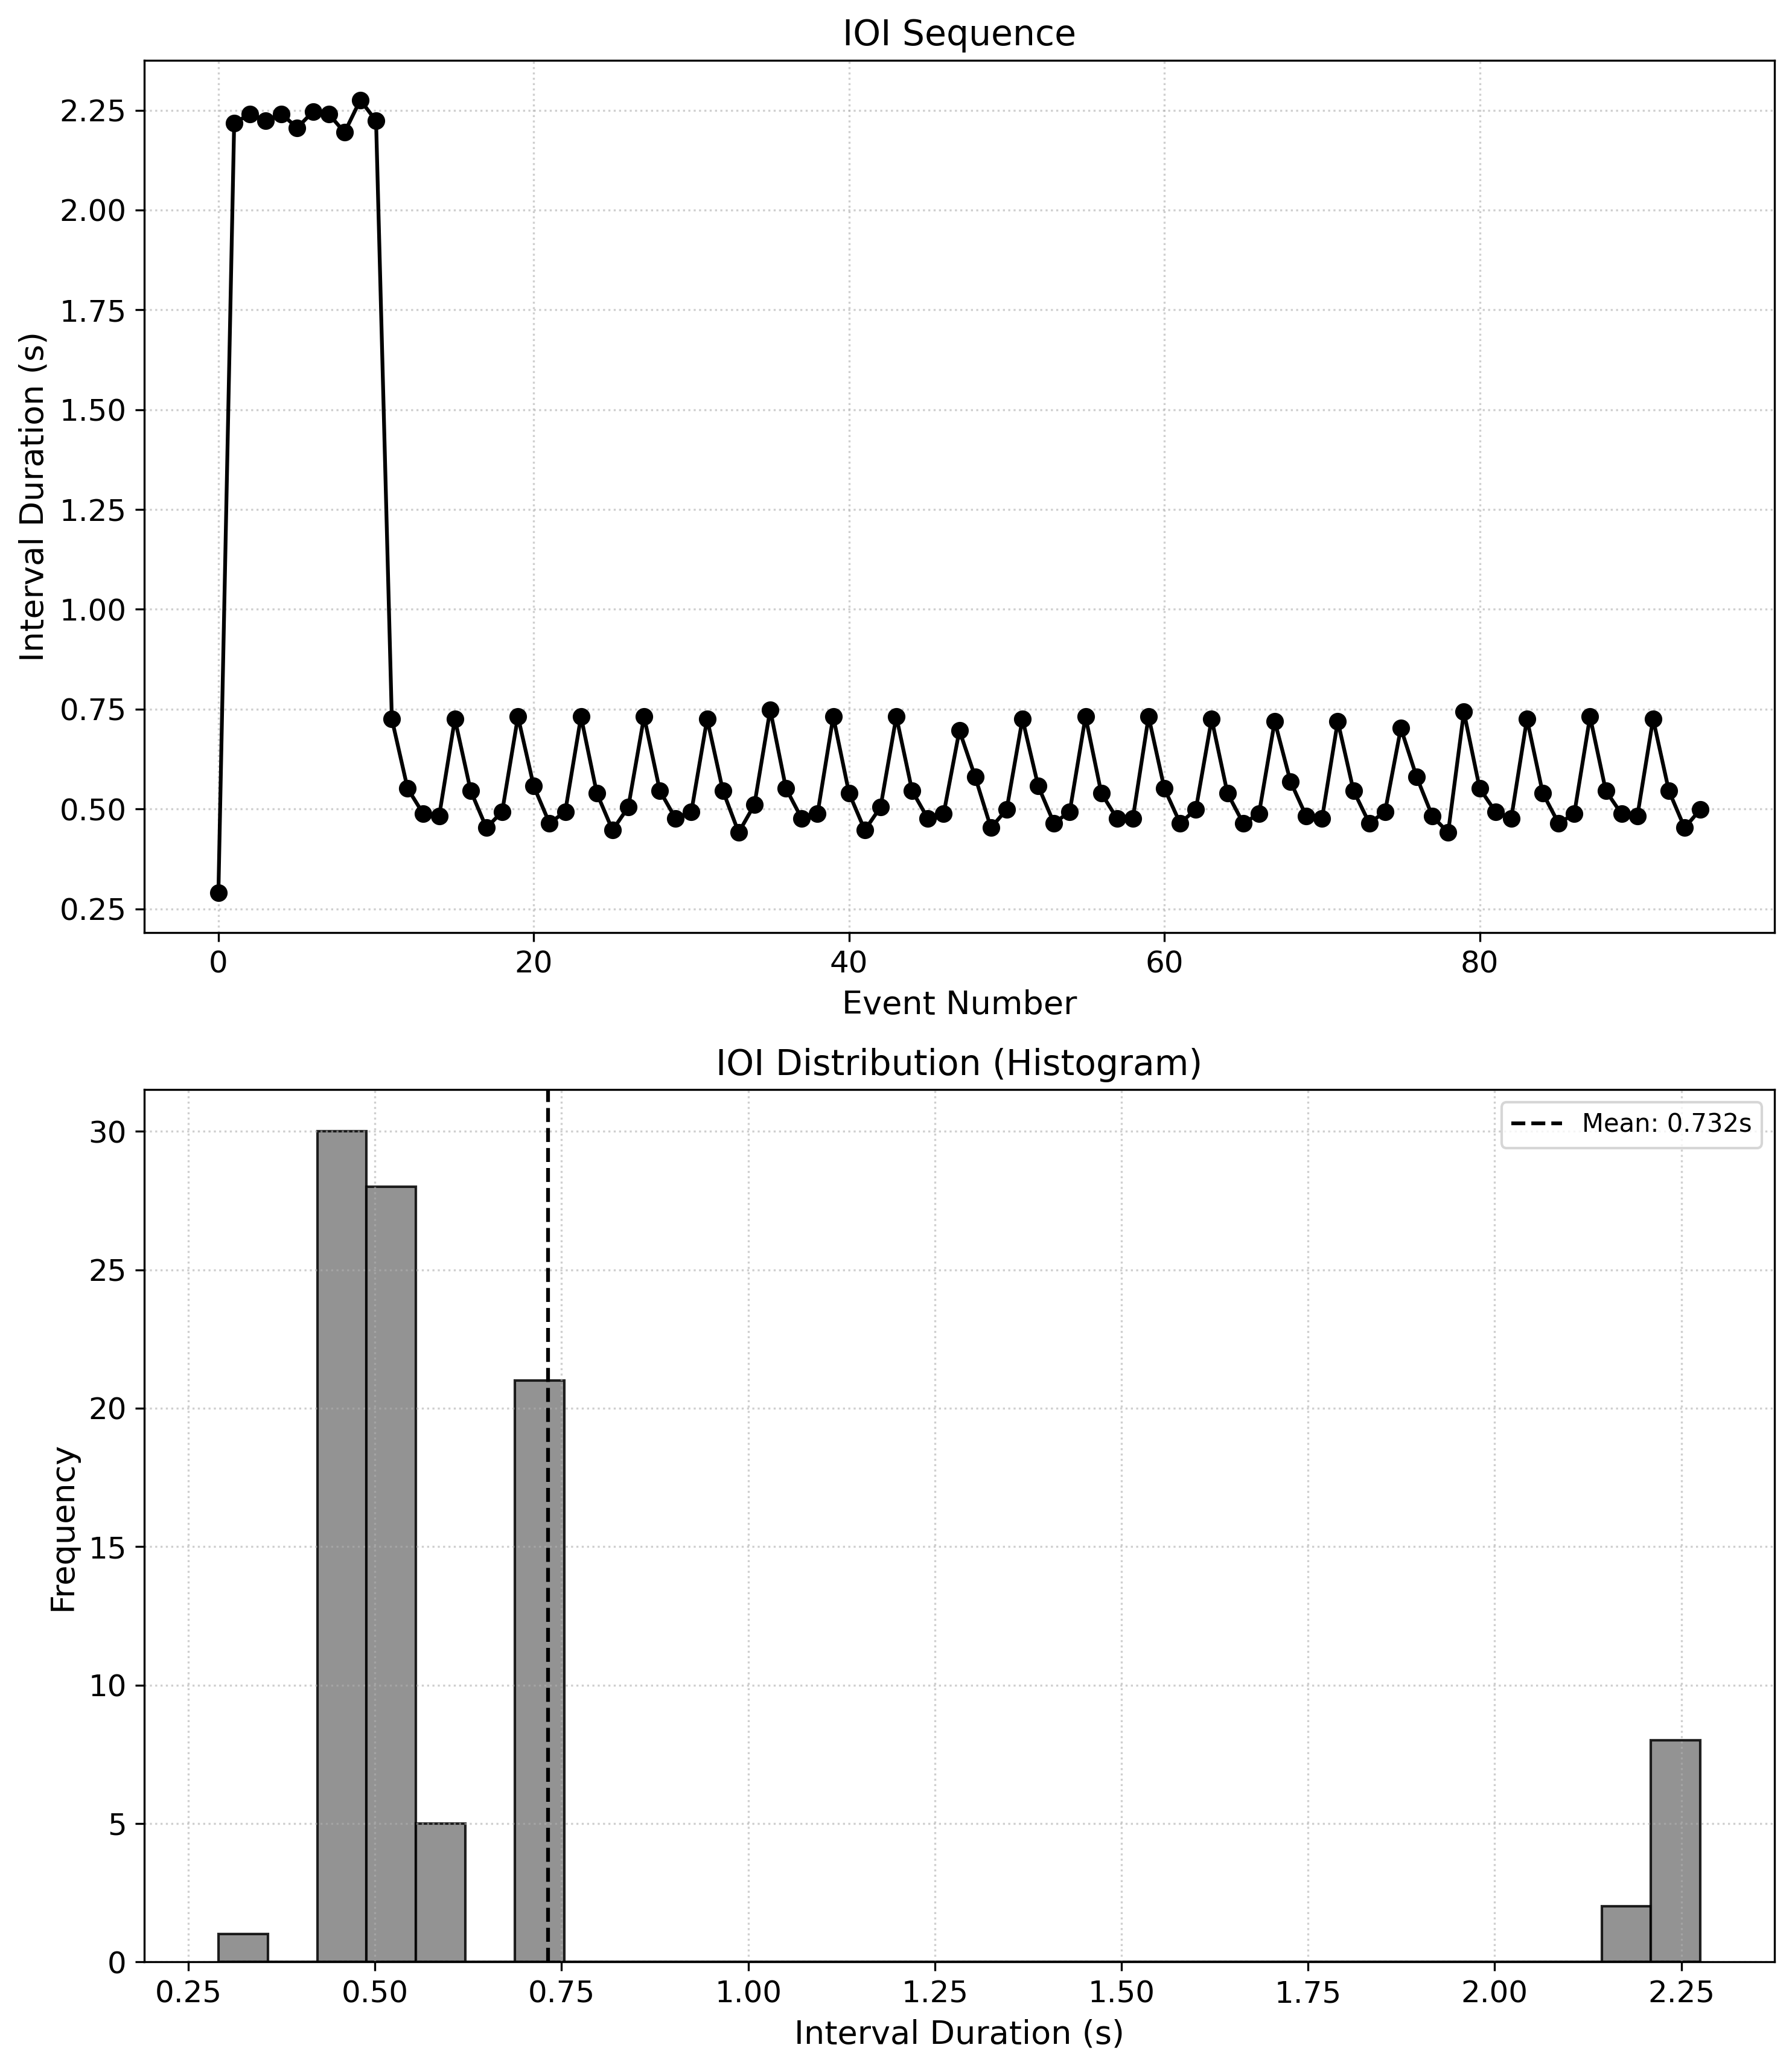


--- Step 2: Searching for Optimal Grid Period (Range: 0.1s - 1s) ---


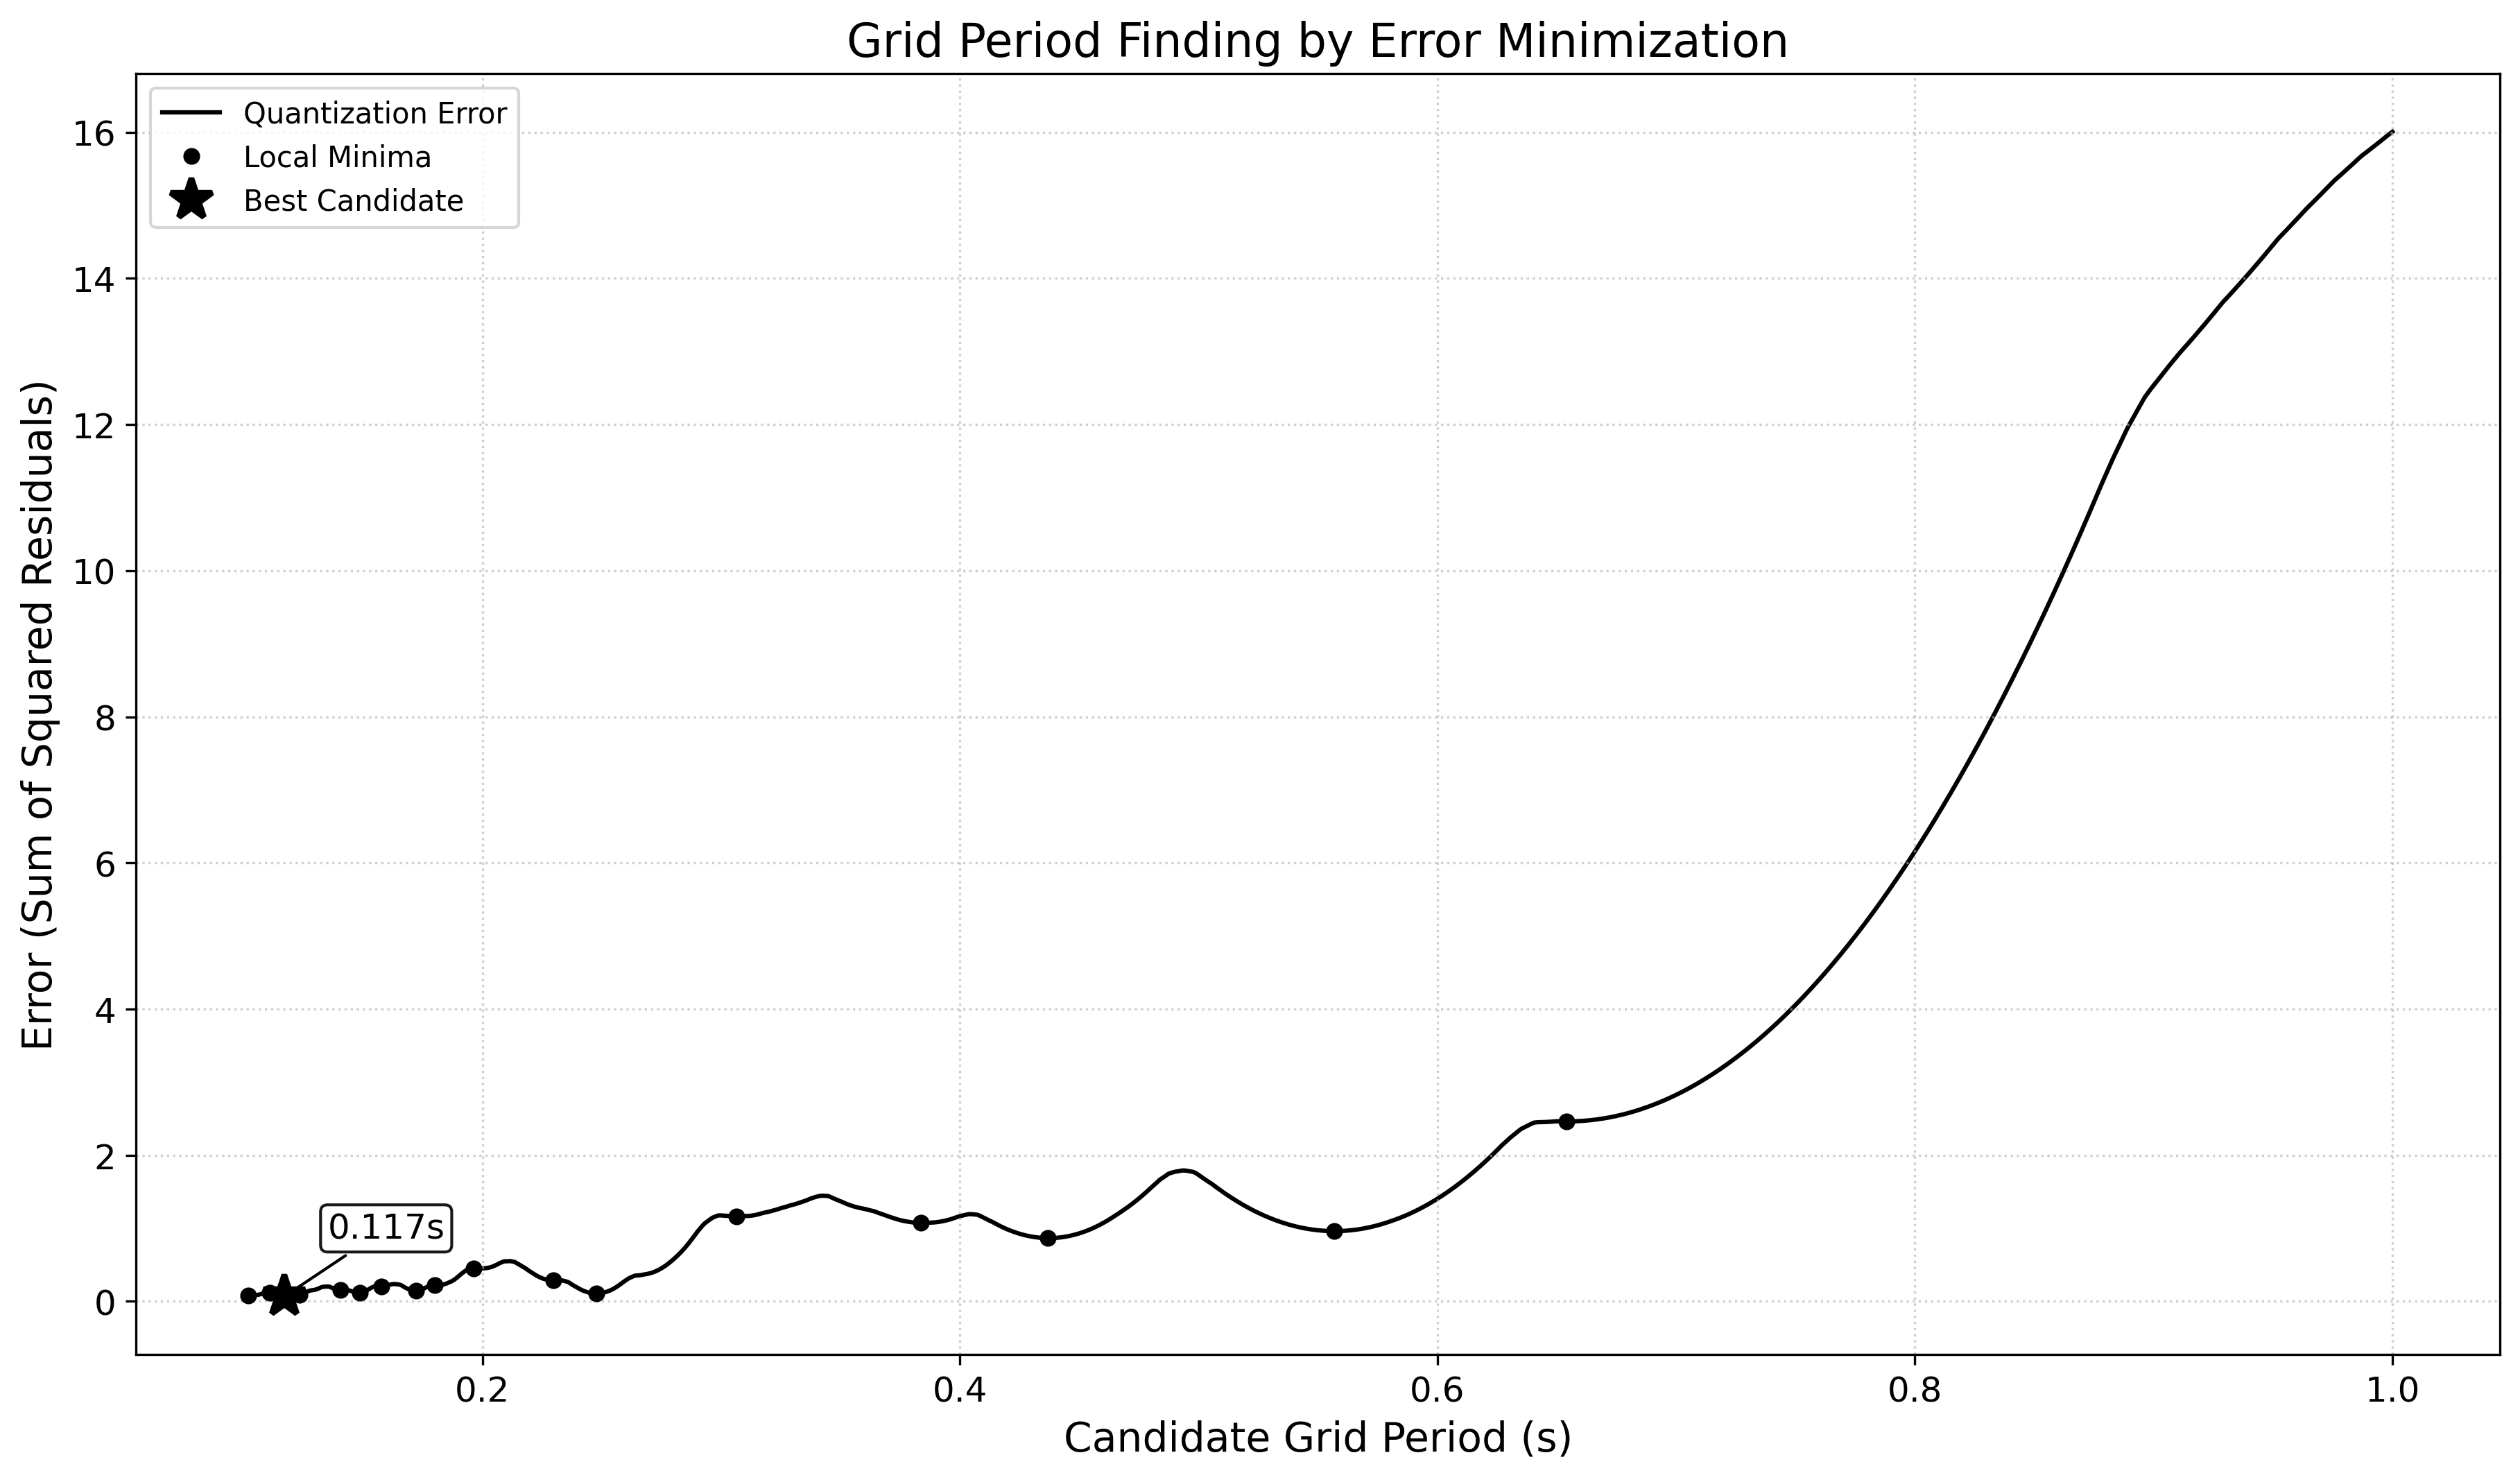


Top 5 potential grid period(s) (sorted by error):
  - Period: 0.1171 s,  Error (Loss): 0.0687  <-- Best (lowest error)
  - Period: 0.1018 s,  Error (Loss): 0.0809
  - Period: 0.1234 s,  Error (Loss): 0.0928
  - Period: 0.2477 s,  Error (Loss): 0.1085
  - Period: 0.1486 s,  Error (Loss): 0.1135
-------------------------------------------------------

--- Step 3: Evaluating the Chosen Candidate Grid ---
Automatically evaluating best-fit period: 0.1171 s

--- Timing Deviation (Residual) Analysis ---
Mean Residual:   +3.14 ms
Median Residual: +7.54 ms
Std. Deviation:  26.85 ms (Jitter)
Interpretation: The timing is very close to the grid model (low bias).
--------------------------------------------


C:\Users\egorp\Nextcloud\code\public_repos\beat_it\py_scripts\ioi_analysis_toolkit.py:261: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96]);


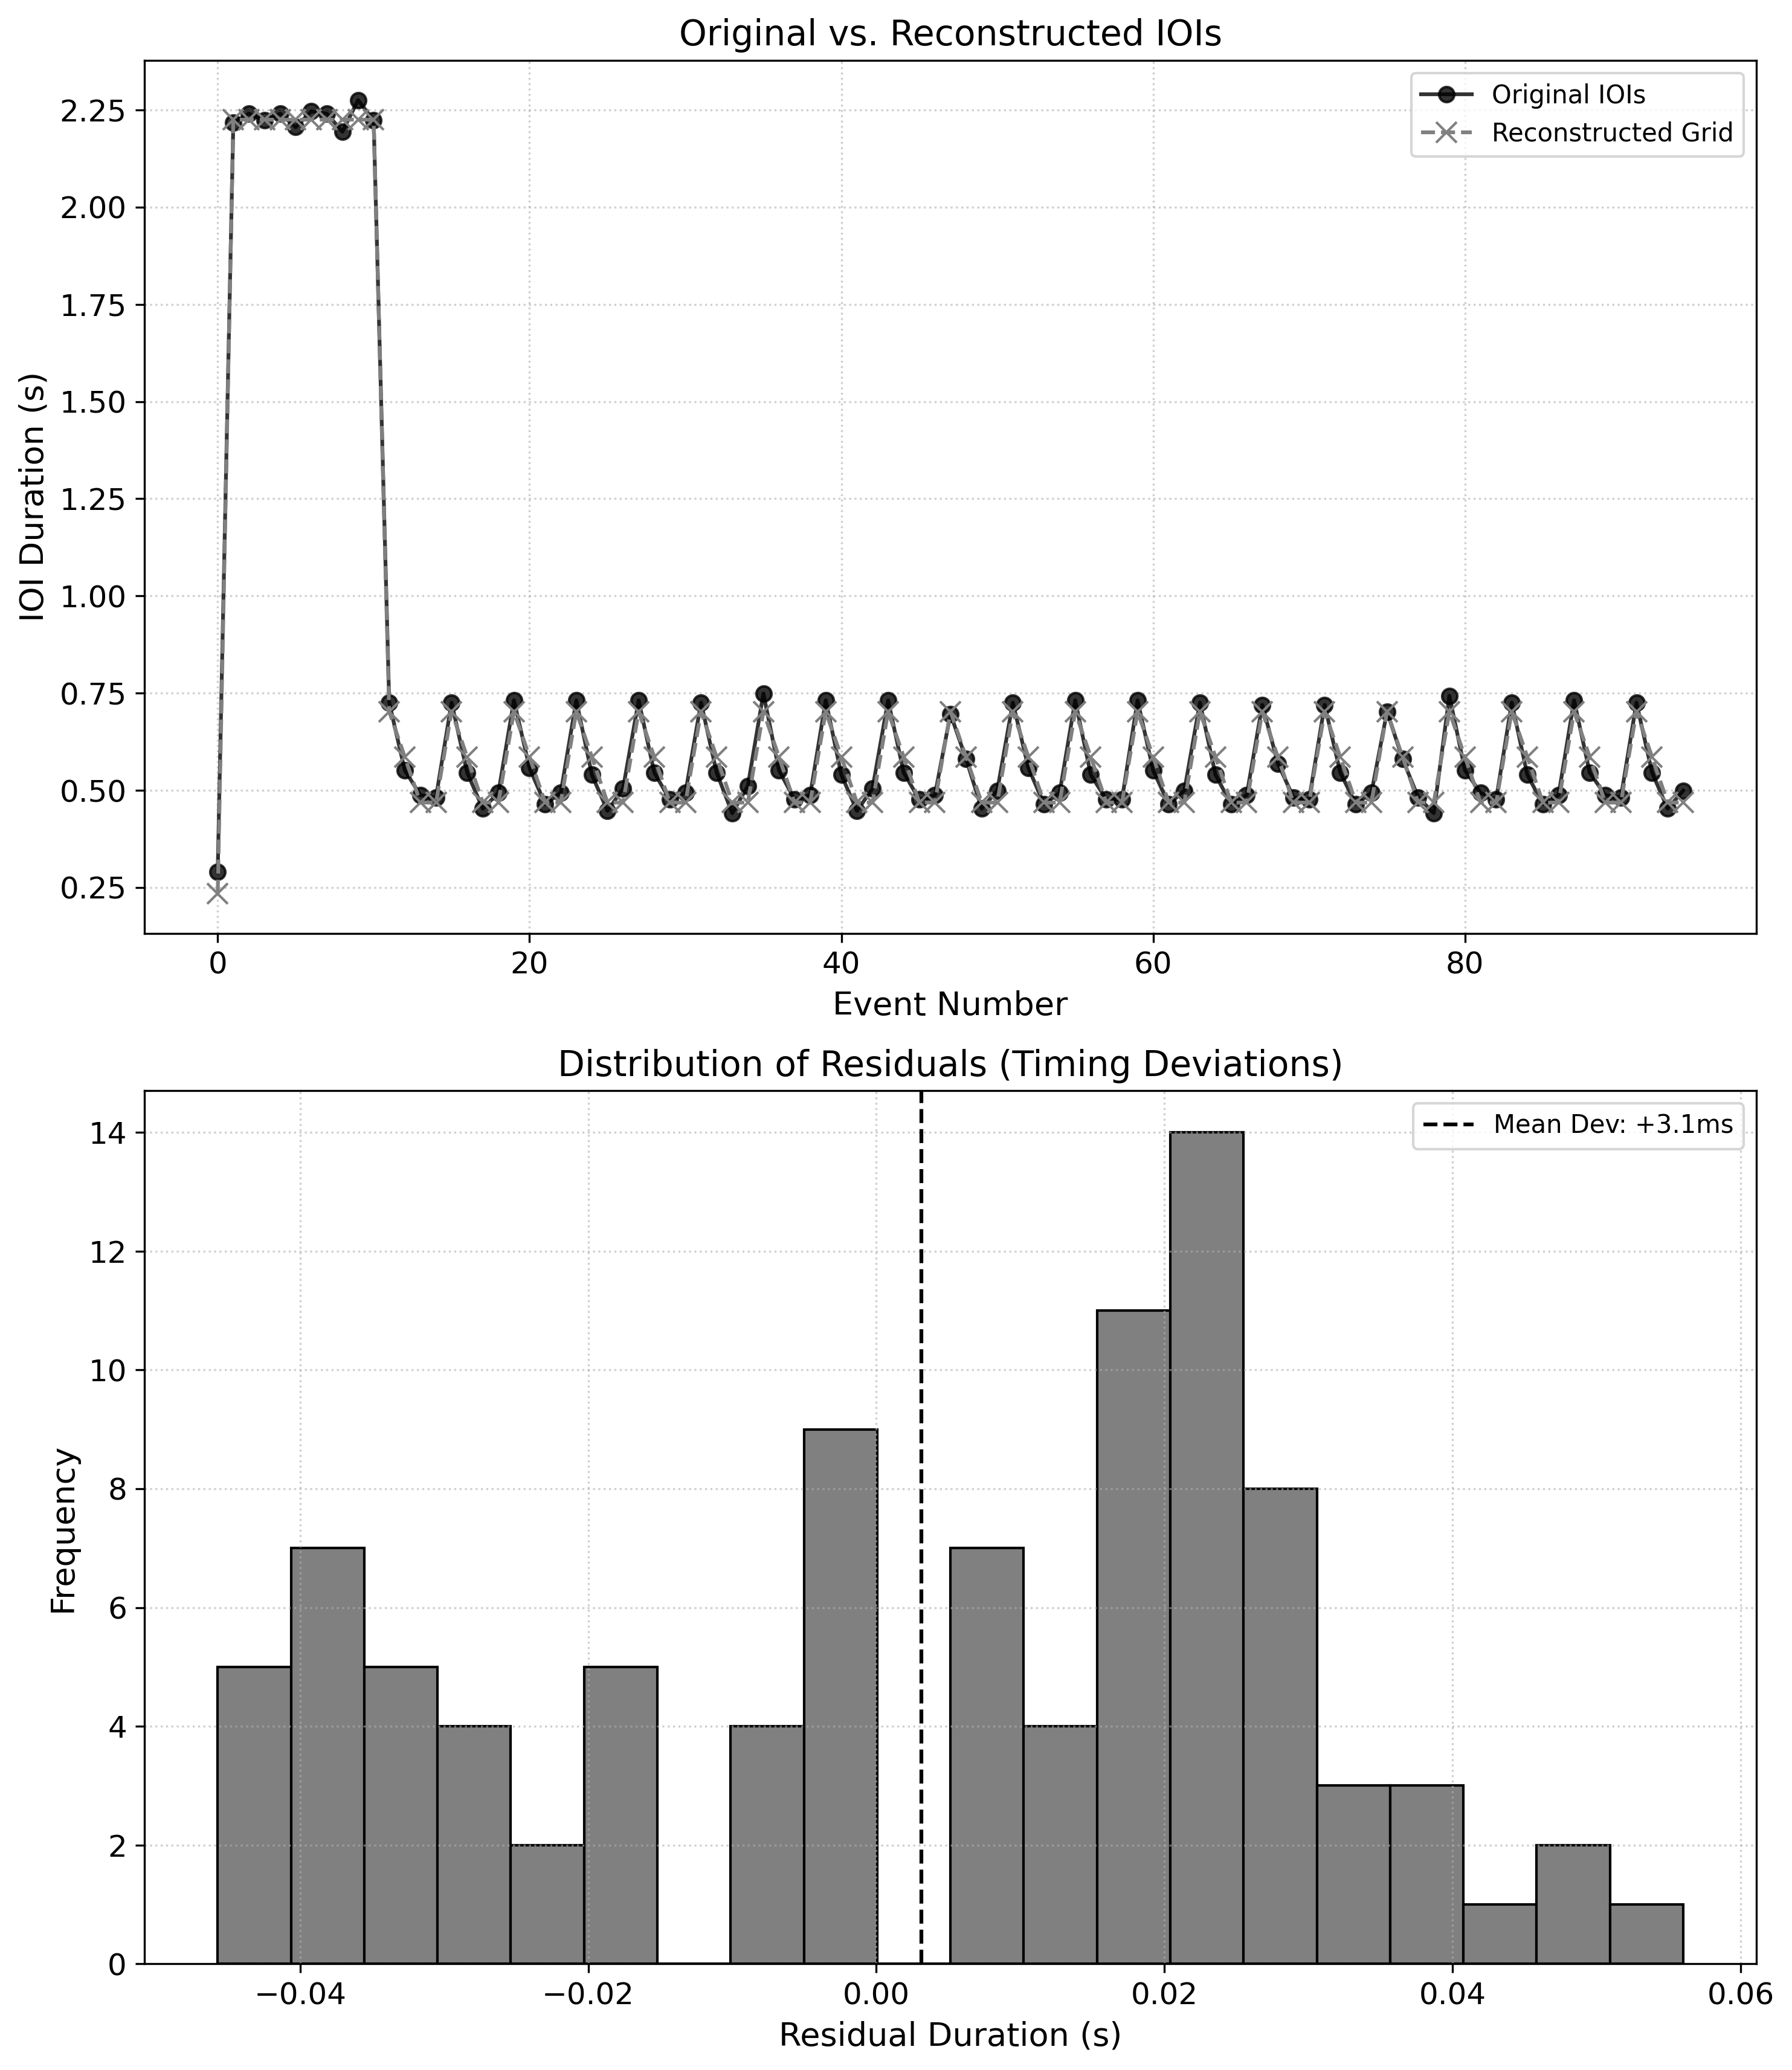


Analysis Results Table (first 5 rows):


,Original_IOI,Multiplier,Reconstructed_IOI,Residual
0,0.290249,2,0.234234,0.056015
1,2.217506,19,2.225225,-0.007720
2,2.240726,19,2.225225,0.015500
3,2.223311,19,2.225225,-0.001915
4,2.240726,19,2.225225,0.015500


In [4]:
# ===================================================================
#                      IOI ANALYSIS WORKFLOW
# ===================================================================

# --- 1. Imports and Setup ---
import pandas as pd
import numpy as np

# Import the functions from your custom toolkit
# Make sure the 'ioi_analysis_toolkit.py' file is in the same directory or your Python path.
from py_scripts.ioi_analysis_toolkit import analyze_iois, find_optimal_grid_period, evaluate_grid_fit

# ===================================================================
#                      3. CONFIGURE THE ANALYSIS
# ===================================================================

# --- Data Configuration ---
# The name of the column in your DataFrame containing the onset times in seconds.
ONSET_COLUMN_NAME = 'onset_times'

# --- Grid Search Configuration ---
# The search range for the underlying grid period.
MIN_GRID_PERIOD_S = 0.1
MAX_GRID_PERIOD_S = 1
# How many of the best candidates to label on the plot and list in the output.
TOP_N_CANDIDATES = 5

# --- Evaluation Configuration ---
# To manually select a period, set this to a number (e.g., 0.247).
# To use the automatic best-fit from the search, set this to None.
MANUAL_GRID_PERIOD_S = None # <-- SET A VALUE HERE TO OVERRIDE AUTOMATIC SELECTION

# --- Results Display Configuration ---
# Set to True to see the full table of IOIs, multipliers, and residuals.
SHOW_FULL_RESULTS_DF = False


# ===================================================================
#                    4. EXECUTE THE ANALYSIS WORKFLOW
# ===================================================================

if 'df' in locals() and isinstance(df, pd.DataFrame):
    
    # --- Step 1: Perform Initial IOI Analysis ---
    print("\n\n--- Step 1: Initial IOI Analysis ---")
    iois, ioi_stats = analyze_iois(df, onset_column=ONSET_COLUMN_NAME, grayscale=GRAYSCALE, font_scale=FONT_SCALE, dpi=DPI, layout='vertical', show_legend=True)

    if iois.size > 0:
        # --- Step 2: Find Candidate Grid Periods ---
        print(f"\n--- Step 2: Searching for Optimal Grid Period (Range: {MIN_GRID_PERIOD_S}s - {MAX_GRID_PERIOD_S}s) ---")
        sorted_periods, sorted_errors = find_optimal_grid_period(
            iois, 
            min_period=MIN_GRID_PERIOD_S, 
            max_period=MAX_GRID_PERIOD_S,
            top_n_to_label=TOP_N_CANDIDATES,
            grayscale=GRAYSCALE,
            font_scale=FONT_SCALE,
            dpi=DPI,
        )
        
        if sorted_periods.size > 0:
            print(f"\nTop {min(TOP_N_CANDIDATES, len(sorted_periods))} potential grid period(s) (sorted by error):")
            for i, (period, error) in enumerate(zip(sorted_periods, sorted_errors)):
                if i >= TOP_N_CANDIDATES: break
                marker = "  <-- Best (lowest error)" if i == 0 else ""
                print(f"  - Period: {period:.4f} s,  Error (Loss): {error:.4f}{marker}")
            print("-" * 55 + "\n")

            # --- Step 3: Evaluate the Chosen Candidate ---
            print("--- Step 3: Evaluating the Chosen Candidate Grid ---")
            
            if MANUAL_GRID_PERIOD_S is not None:
                chosen_period = MANUAL_GRID_PERIOD_S
                print(f"Manually evaluating user-specified period: {chosen_period:.4f} s")
            else:
                chosen_period = sorted_periods[0]
                print(f"Automatically evaluating best-fit period: {chosen_period:.4f} s")
            
            results_df = evaluate_grid_fit(iois, chosen_period, grayscale=GRAYSCALE, font_scale=FONT_SCALE, dpi=DPI, layout='vertical')
            
            if SHOW_FULL_RESULTS_DF:
                print("\nDisplaying full Analysis Results Table:")
                display(results_df)
            else:
                print("\nAnalysis Results Table (first 5 rows):")
                display(results_df.head())
        else:
            print("\nCould not find any distinct grid periods in the specified range.")
else:
    print("\nERROR: DataFrame 'df' not found. Please load or create your data in Step 2.")

Analyzing 95 timing residuals...

--- Method 1: Residuals vs. Event Number ---


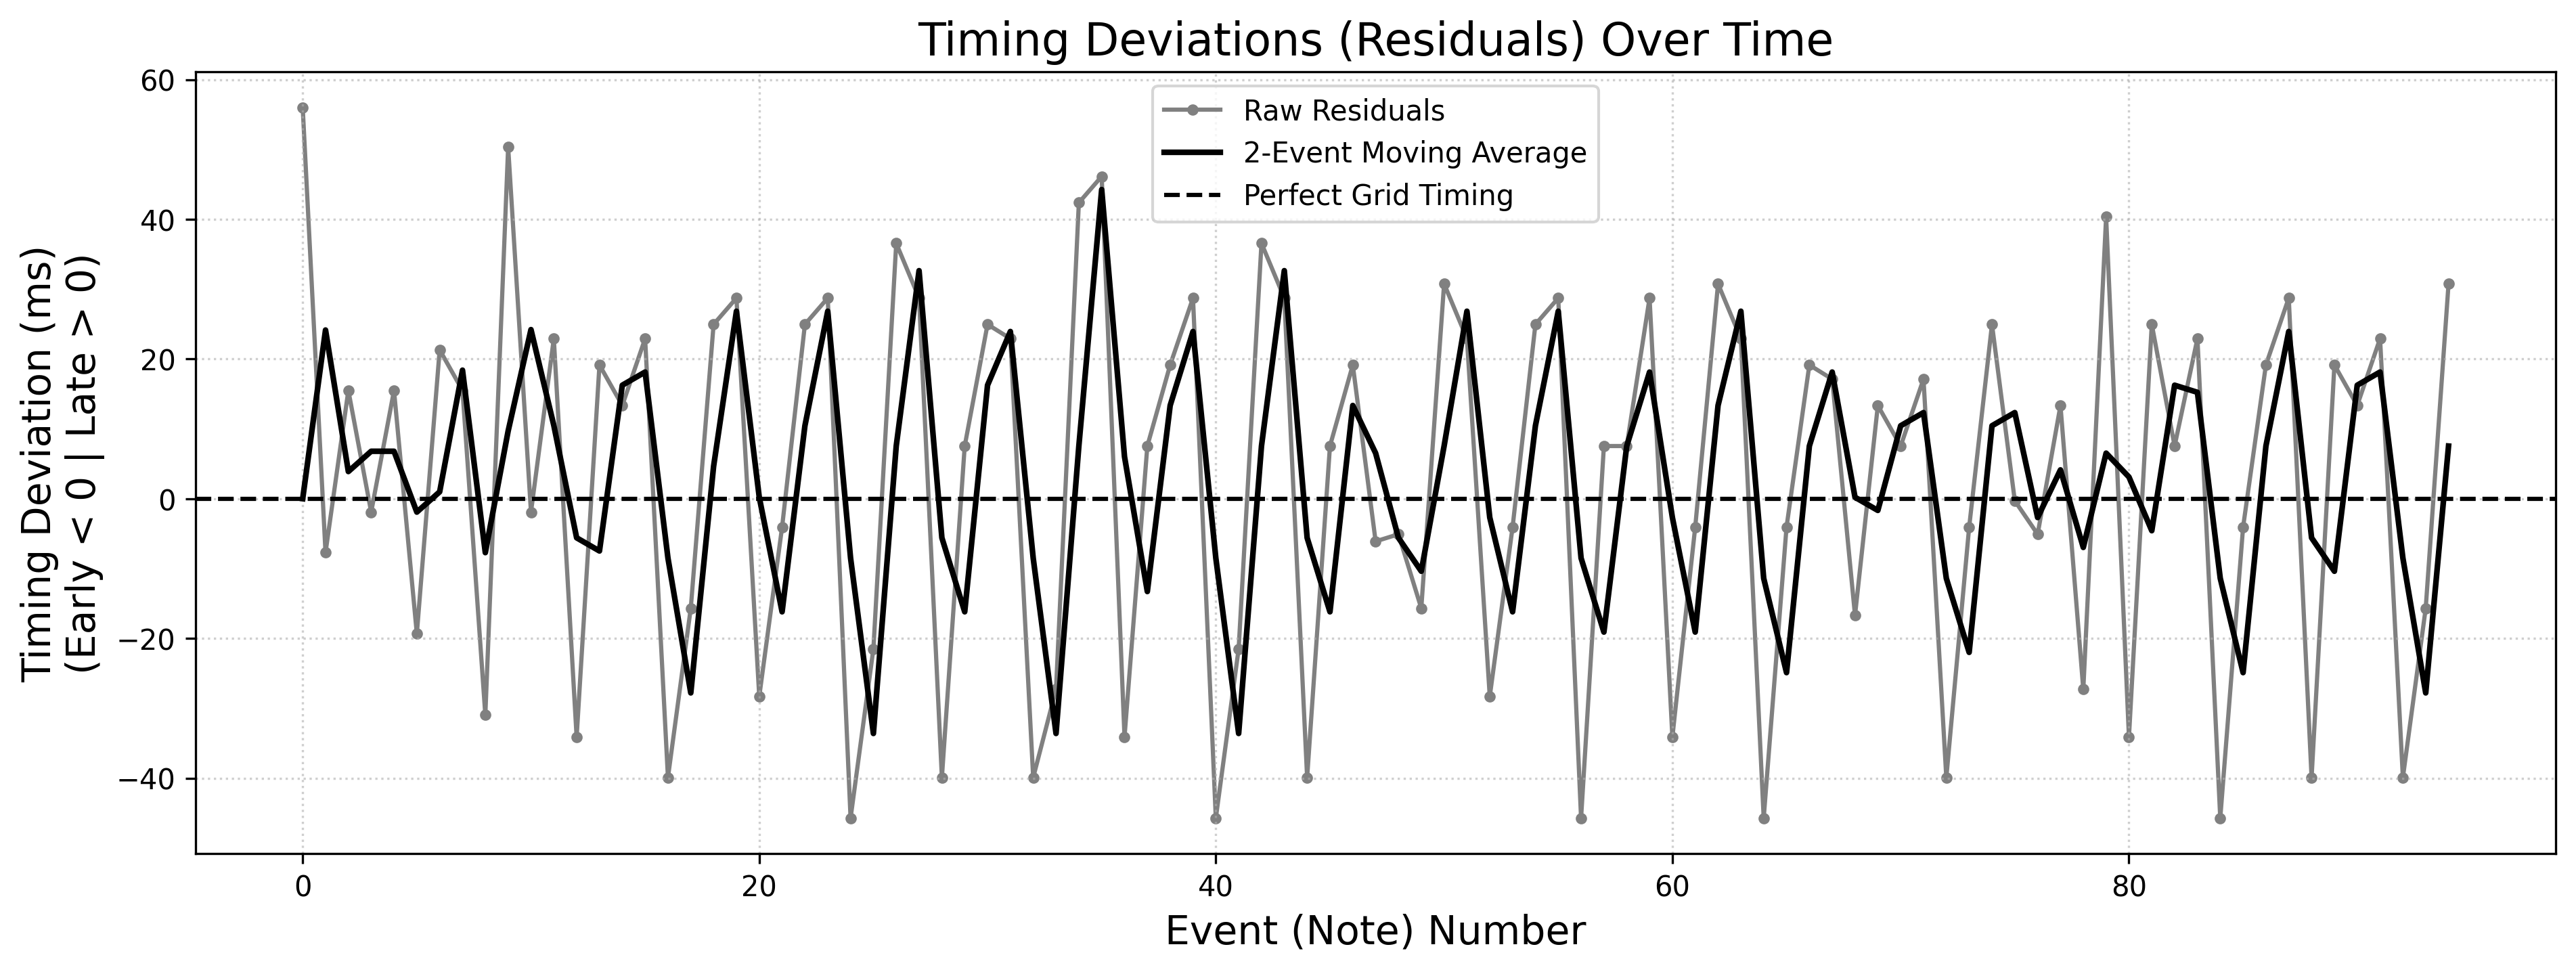

  > Visual check: Does the red line show a drift or a wave-like pattern?

--- Method 2: Autocorrelation of Residuals ---


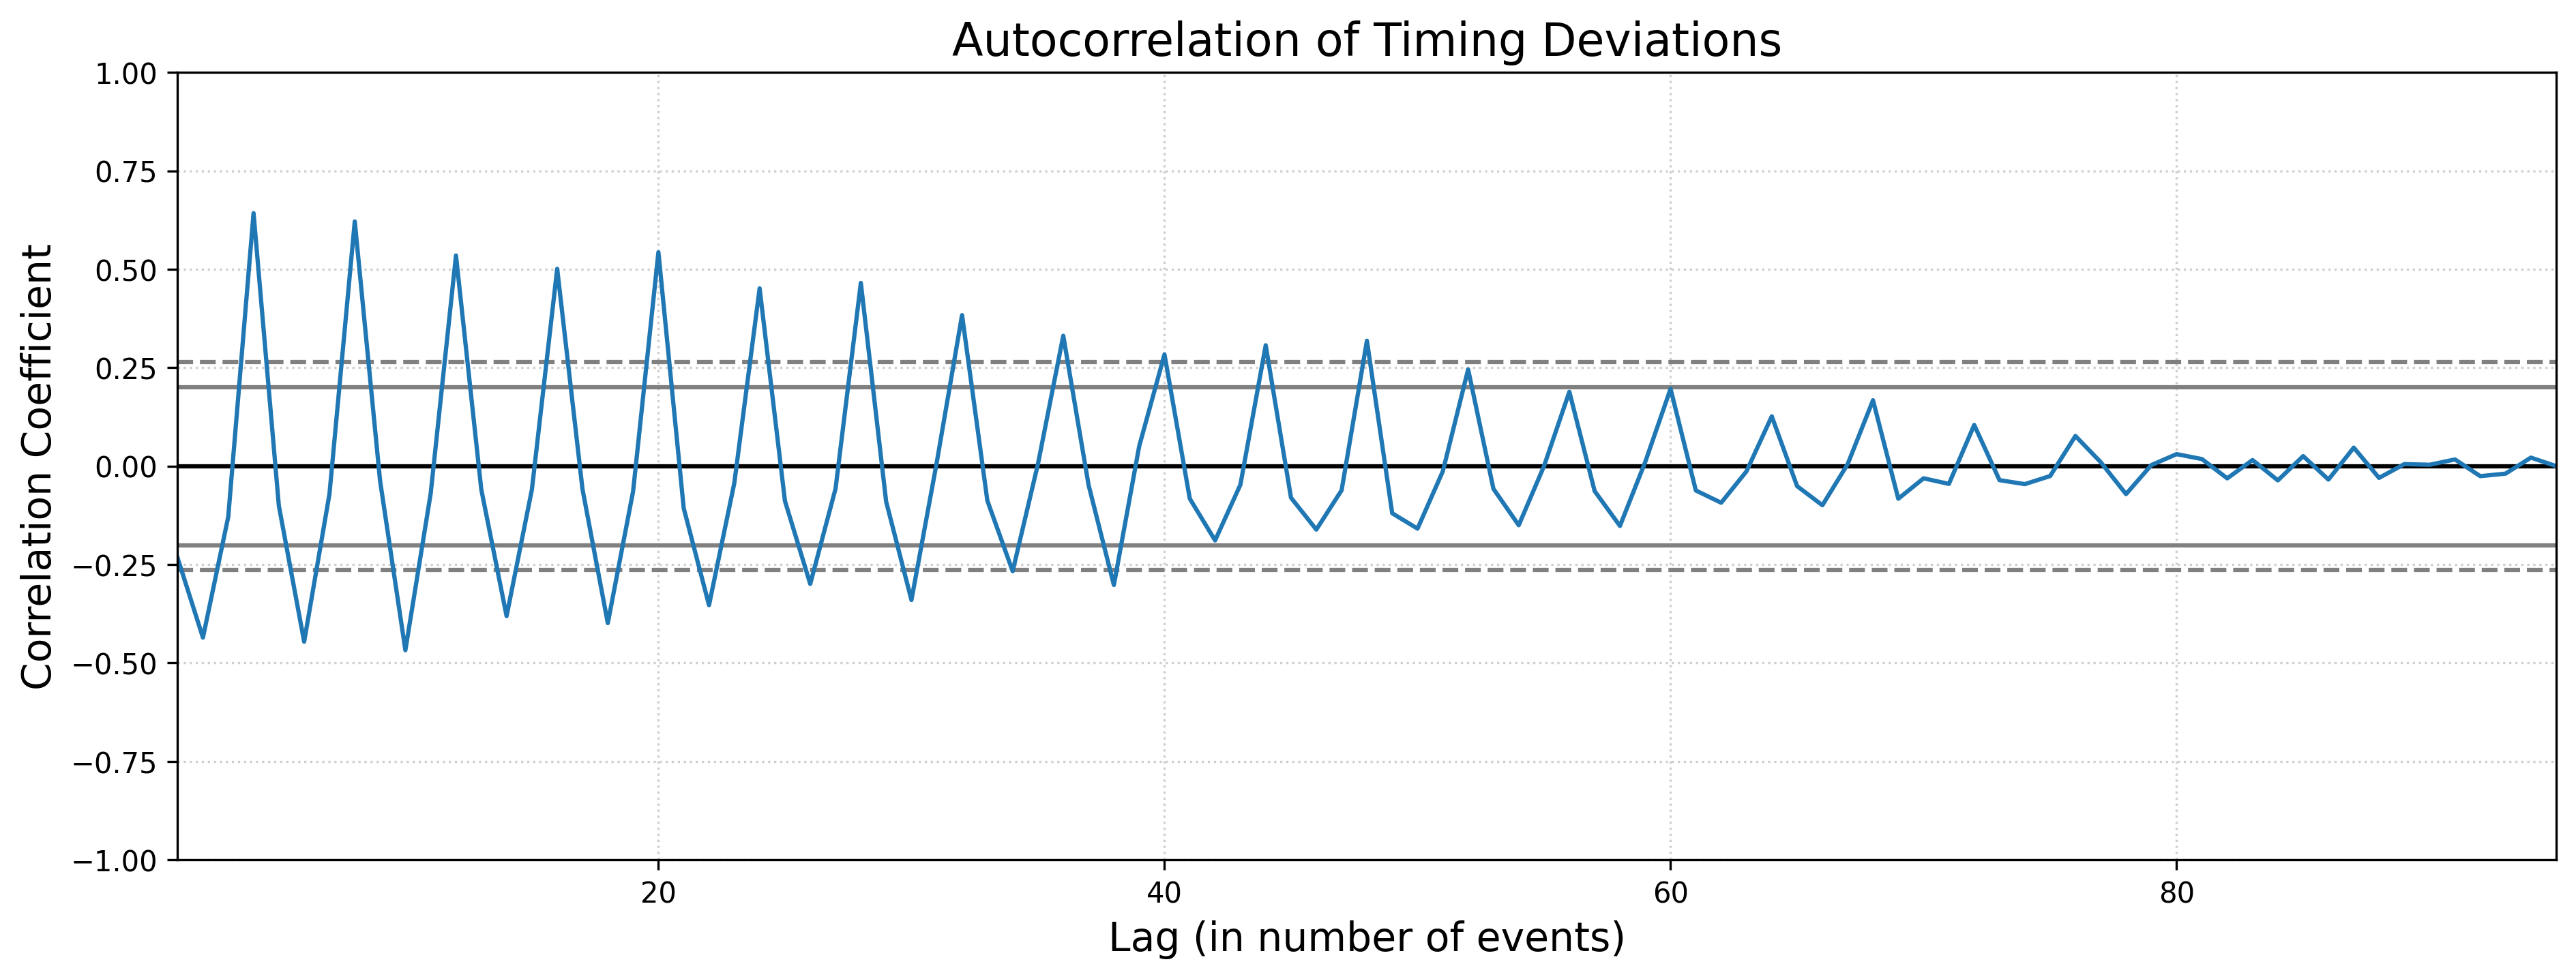

  > Visual check: Are there significant peaks at lags like 2, 4, or 8?

--- Method 3: Self-Similarity Matrix ---


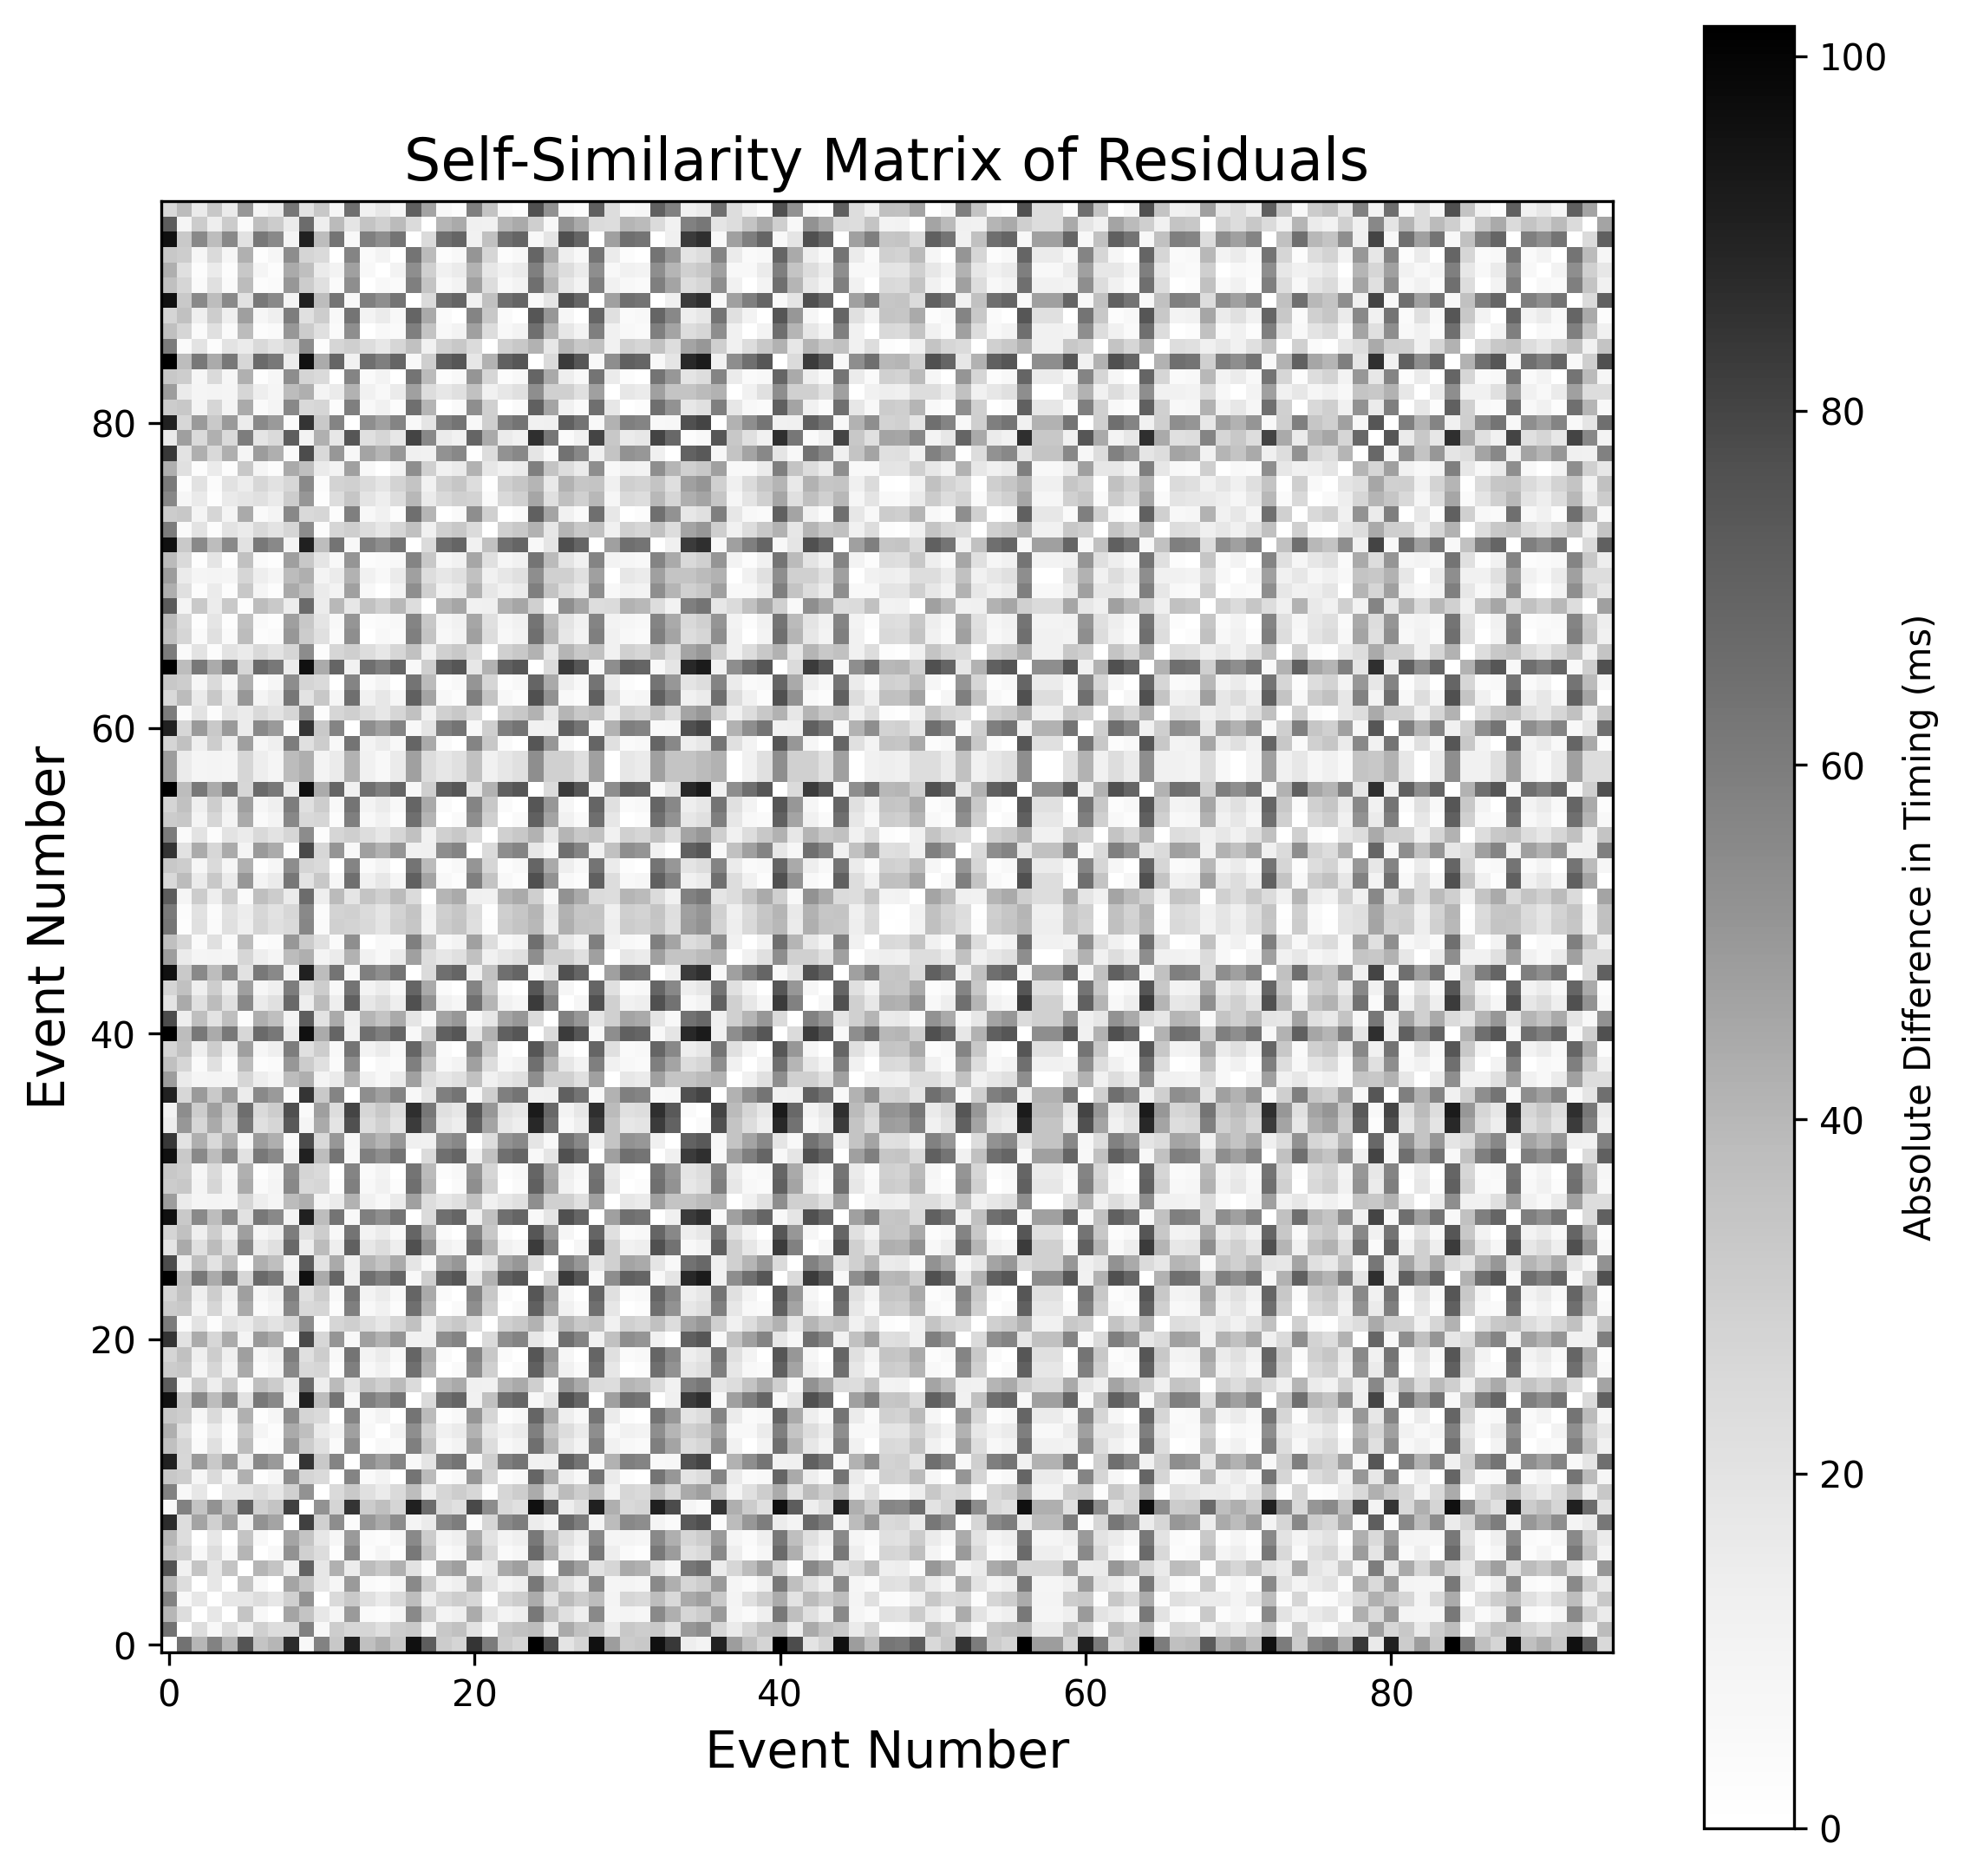

  > Visual check: Do you see bright lines parallel to the diagonal or checkerboard patterns?


--- Method 4: Automated Pattern & Loop Detection ---

[A] Analyzing with Autocorrelation...
  > RESULT: Found a significant peak at lag=4.
  > INTERPRETATION: This suggests a repeating pattern every 4 events.
    A period of 4 could correspond to a repeating measure-level rhythmic feel in 4/4 time.

[B] Analyzing with Fast Fourier Transform (FFT)...
  > RESULT: Found a dominant frequency component at 0.253 cycles/event.
  > INTERPRETATION: This corresponds to a repeating cycle every 3.96 events.


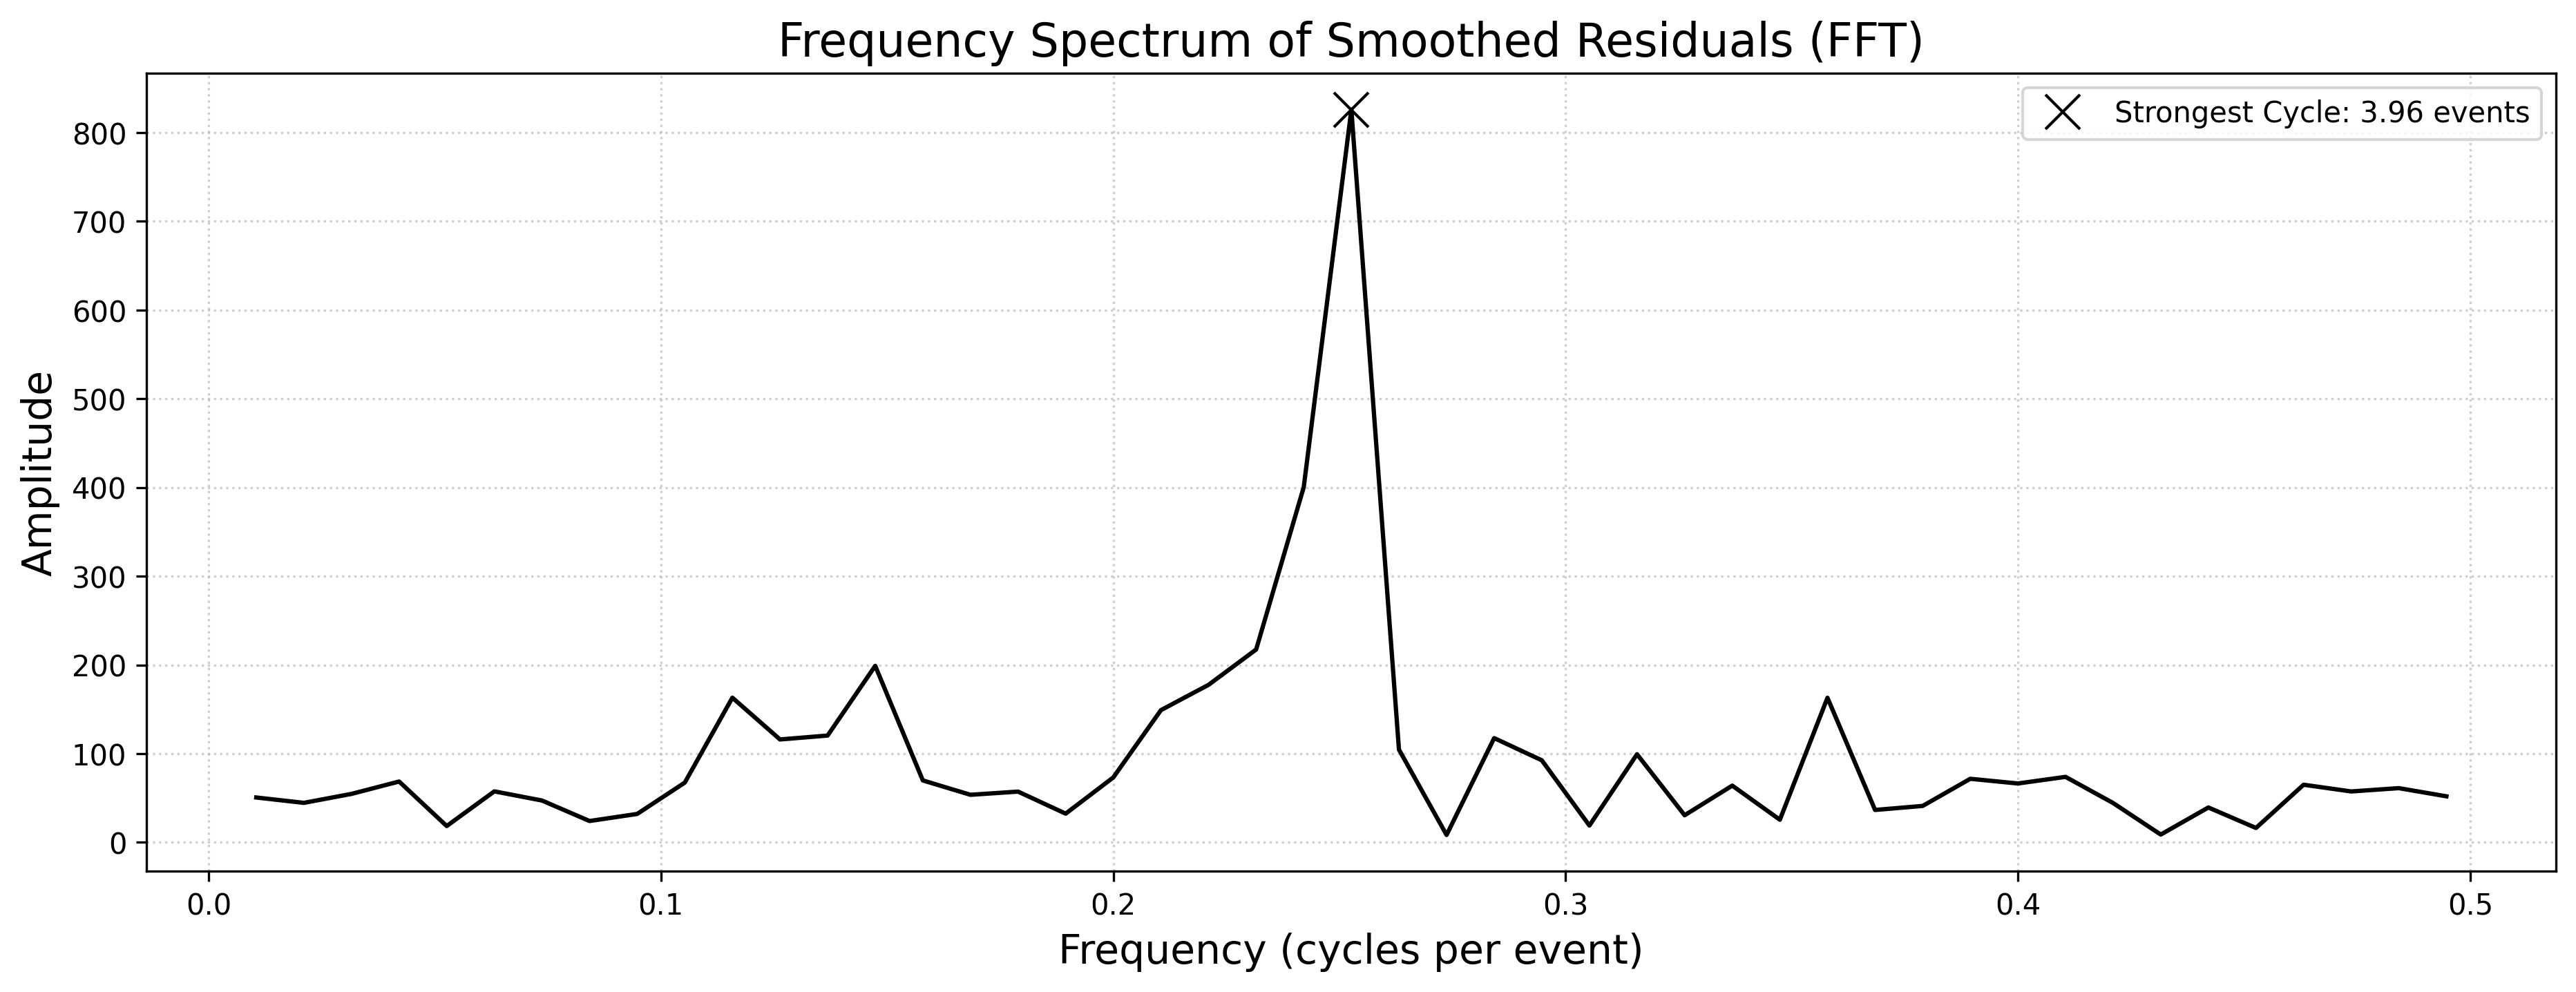


[C] Overall Conclusion
  The analysis points towards a recurring pattern with a period of approximately 4 events.
  The FFT analysis corroborates this, finding a similar cycle length of 3.96 events.
  CONCLUSION: There is strong evidence of a repeating rhythmic feel.


In [5]:
# ===================================================================
#           CELL 4: RESIDUAL PATTERN ANALYSIS (ENHANCED)
# This cell analyzes the sequence of timing deviations to find
# recurring patterns, drift, or rhythmic swing.
# It requires 'results_df' to be created by the main analysis cell.
# ===================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from scipy.signal import find_peaks
from scipy.fft import rfft, rfftfreq

# --- Pre-computation Check ---
if 'results_df' not in locals() or results_df.empty:
    print("CRITICAL ERROR: DataFrame 'results_df' not found or is empty.")
    print("Please run the main analysis cell successfully before running this one.")
else:
    # Extract the residual series in milliseconds for easier interpretation
    residuals_ms = results_df['Residual'].values * 1000
    print(f"Analyzing {len(residuals_ms)} timing residuals...")

    # ===============================================================
    # --- METHOD 1: Plotting Residuals Over Time (Visual Inspection)
    # ===============================================================
    print("\n--- Method 1: Residuals vs. Event Number ---")
    plt.figure(figsize=(15, 5), dpi=DPI)
    
    plt.plot(residuals_ms, 'o-', color=('gray' if GRAYSCALE else 'lightgray'), markersize=3, label='Raw Residuals', zorder=1)
    
    moving_avg_window = 2
    # Use .fillna(0) to handle edges where the centered window has no data
    smoothed_residuals = results_df['Residual'].rolling(window=moving_avg_window, center=True).mean().fillna(0) * 1000
    plt.plot(smoothed_residuals, color=('black' if GRAYSCALE else 'crimson'), linewidth=2, label=f'{moving_avg_window}-Event Moving Average', zorder=2)
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Perfect Grid Timing')
    plt.title('Timing Deviations (Residuals) Over Time', fontsize=int(14 * FONT_SCALE))
    plt.xlabel('Event (Note) Number', fontsize=int(12 * FONT_SCALE))
    plt.ylabel('Timing Deviation (ms)\n(Early < 0 | Late > 0)', fontsize=int(12 * FONT_SCALE))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()
    print("  > Visual check: Does the red line show a drift or a wave-like pattern?")

    # ===============================================================
    # --- METHOD 2: Autocorrelation Plot (Visual Inspection)
    # ===============================================================
    print("\n--- Method 2: Autocorrelation of Residuals ---")
    plt.figure(figsize=(15, 5), dpi=DPI)
    autocorrelation_plot(residuals_ms)
    plt.title('Autocorrelation of Timing Deviations', fontsize=int(14 * FONT_SCALE))
    plt.xlabel('Lag (in number of events)', fontsize=int(12 * FONT_SCALE))
    plt.ylabel('Correlation Coefficient', fontsize=int(12 * FONT_SCALE))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    print("  > Visual check: Are there significant peaks at lags like 2, 4, or 8?")
    
    # ===============================================================
    # --- METHOD 3: Self-Similarity Matrix (Visual Inspection)
    # ===============================================================
    print("\n--- Method 3: Self-Similarity Matrix ---")
    residuals_col = residuals_ms[:, np.newaxis]
    residuals_row = residuals_ms[np.newaxis, :]
    ssm = np.abs(residuals_col - residuals_row)

    plt.figure(figsize=(9, 9), dpi=DPI)
    plt.imshow(ssm, cmap=('Greys' if GRAYSCALE else 'magma_r'), interpolation='nearest', origin='lower')
    plt.title('Self-Similarity Matrix of Residuals', fontsize=int(14 * FONT_SCALE))
    plt.xlabel('Event Number', fontsize=int(12 * FONT_SCALE)); plt.ylabel('Event Number', fontsize=int(12 * FONT_SCALE))
    cbar = plt.colorbar(); cbar.set_label('Absolute Difference in Timing (ms)')
    plt.show()
    print("  > Visual check: Do you see bright lines parallel to the diagonal or checkerboard patterns?")

    # ===============================================================
    # --- METHOD 4: AUTOMATED PATTERN & LOOP DETECTION
    # This method programmatically analyzes the smoothed residuals.
    # ===============================================================
    print("\n\n" + "="*50)
    print("--- Method 4: Automated Pattern & Loop Detection ---")
    print("="*50)
    
    # Use the smoothed data for analysis, as it represents the core pattern
    analysis_signal = smoothed_residuals.values
    
    # --- Part A: Autocorrelation Peak Analysis ---
    print("\n[A] Analyzing with Autocorrelation...")
    
    # We compute autocorrelation manually to get the values for peak finding
    # We subtract the mean to focus on the shape of the pattern
    autocorr = np.correlate(analysis_signal - analysis_signal.mean(), analysis_signal - analysis_signal.mean(), mode='full')
    autocorr = autocorr[autocorr.size // 2:] # Keep only the second half (positive lags)
    
    # Find peaks. The 'height' parameter filters out minor noise peaks.
    # The 'distance' ensures we don't find multiple peaks for the same underlying pattern.
    peaks, _ = find_peaks(autocorr, height=np.std(autocorr), distance=2)
    
    if len(peaks) > 0:
        # The first peak is often the most important one for identifying the fundamental pattern
        primary_lag = peaks[0]
        print(f"  > RESULT: Found a significant peak at lag={primary_lag}.")
        print(f"  > INTERPRETATION: This suggests a repeating pattern every {primary_lag} events.")
        if primary_lag == 2:
            print("    This is a strong indicator of a 'swing' or alternating early/late pattern.")
        elif primary_lag % 4 == 0:
            print(f"    A period of {primary_lag} could correspond to a repeating measure-level rhythmic feel in 4/4 time.")
    else:
        primary_lag = None
        print("  > RESULT: No significant autocorrelation peaks found.")
        print("  > INTERPRETATION: The timing deviations do not have a strong, regularly repeating pattern.")

    # --- Part B: Fourier Transform (FFT) Analysis ---
    print("\n[B] Analyzing with Fast Fourier Transform (FFT)...")

    N = len(analysis_signal)
    # We only need the positive frequencies for a real-valued signal
    yf = rfft(analysis_signal)
    xf = rfftfreq(N, 1) # The second argument is sample spacing (1 event)

    # Find the peak in the FFT spectrum (ignoring the 0-frequency component, which is the DC offset/mean)
    fft_peaks, _ = find_peaks(np.abs(yf), height=np.std(np.abs(yf)))

    if len(fft_peaks) > 0:
        strongest_peak_idx = fft_peaks[np.argmax(np.abs(yf)[fft_peaks])]
        peak_freq = xf[strongest_peak_idx]
        peak_period = 1 / peak_freq
        print(f"  > RESULT: Found a dominant frequency component at {peak_freq:.3f} cycles/event.")
        print(f"  > INTERPRETATION: This corresponds to a repeating cycle every {peak_period:.2f} events.")

        # --- Plot FFT Spectrum ---
        plt.figure(figsize=(15, 5), dpi=DPI)
        plt.plot(xf[1:], np.abs(yf[1:]), color=('black' if GRAYSCALE else 'navy')) # Plot without DC component for better scaling
        plt.plot(peak_freq, np.abs(yf[strongest_peak_idx]), 'x', color=('black' if GRAYSCALE else 'red'), markersize=12, label=f'Strongest Cycle: {peak_period:.2f} events')
        plt.title('Frequency Spectrum of Smoothed Residuals (FFT)', fontsize=int(14 * FONT_SCALE))
        plt.xlabel('Frequency (cycles per event)', fontsize=int(12 * FONT_SCALE))
        plt.ylabel('Amplitude', fontsize=int(12 * FONT_SCALE))
        plt.grid(True, which='both', linestyle=':', alpha=0.6)
        plt.legend()
        plt.show()

    else:
        peak_period = None
        print("  > RESULT: No dominant frequency component found.")
        print("  > INTERPRETATION: There is no single, strong periodic cycle in the timing data.")


    # --- Part C: Final Conclusion ---
    print("\n[C] Overall Conclusion")
    if primary_lag is not None:
        print(f"  The analysis points towards a recurring pattern with a period of approximately {primary_lag} events.")
        if peak_period is not None and abs(primary_lag - peak_period) < 0.5:
             print(f"  The FFT analysis corroborates this, finding a similar cycle length of {peak_period:.2f} events.")
             print("  CONCLUSION: There is strong evidence of a repeating rhythmic feel.")
        else:
             print("  CONCLUSION: There is moderate evidence of a repeating pattern, primarily from autocorrelation.")

    elif peak_period is not None:
        print(f"  The FFT analysis found a cycle of {peak_period:.2f} events, but it was not strong enough to appear in autocorrelation.")
        print("  CONCLUSION: There may be a weak or complex periodic pattern, but it is not a simple repeating motif.")
    else:
        print("  Both autocorrelation and FFT analysis found no strong evidence of periodicity.")
        print("  CONCLUSION: The timing deviations appear to be largely random (jitter) or a non-repeating drift (accelerando/ritardando) rather than a fixed loop.")

Analyzing 95 timing residuals...


--- Method 1: Sensitivity Analysis for Smoothing Window ---
Analyzing which patterns are strongest at different levels of smoothing.
  - For window size 2 : Strongest pattern repeats every 4 events.
  - For window size 3 : Strongest pattern repeats every 4 events.
  - For window size 4 : Strongest pattern repeats every 8 events.
  - For window size 8 : Strongest pattern repeats every 2 events.
  - For window size 12: No dominant repeating pattern found.
  - For window size 16: No dominant repeating pattern found.

  > INTERPRETATION: Look for a lag number that appears consistently across
    different window sizes. A consistent result indicates a robust pattern.


--- Method 2: Detailed Analysis for Window = 2 ---
[Autocorrelation] Found a repeating motif every 4 events.
[FFT]             Found a cyclical wave every 3.96 events.


--- Method 3: Summary Visualization with Detected Cycles ---


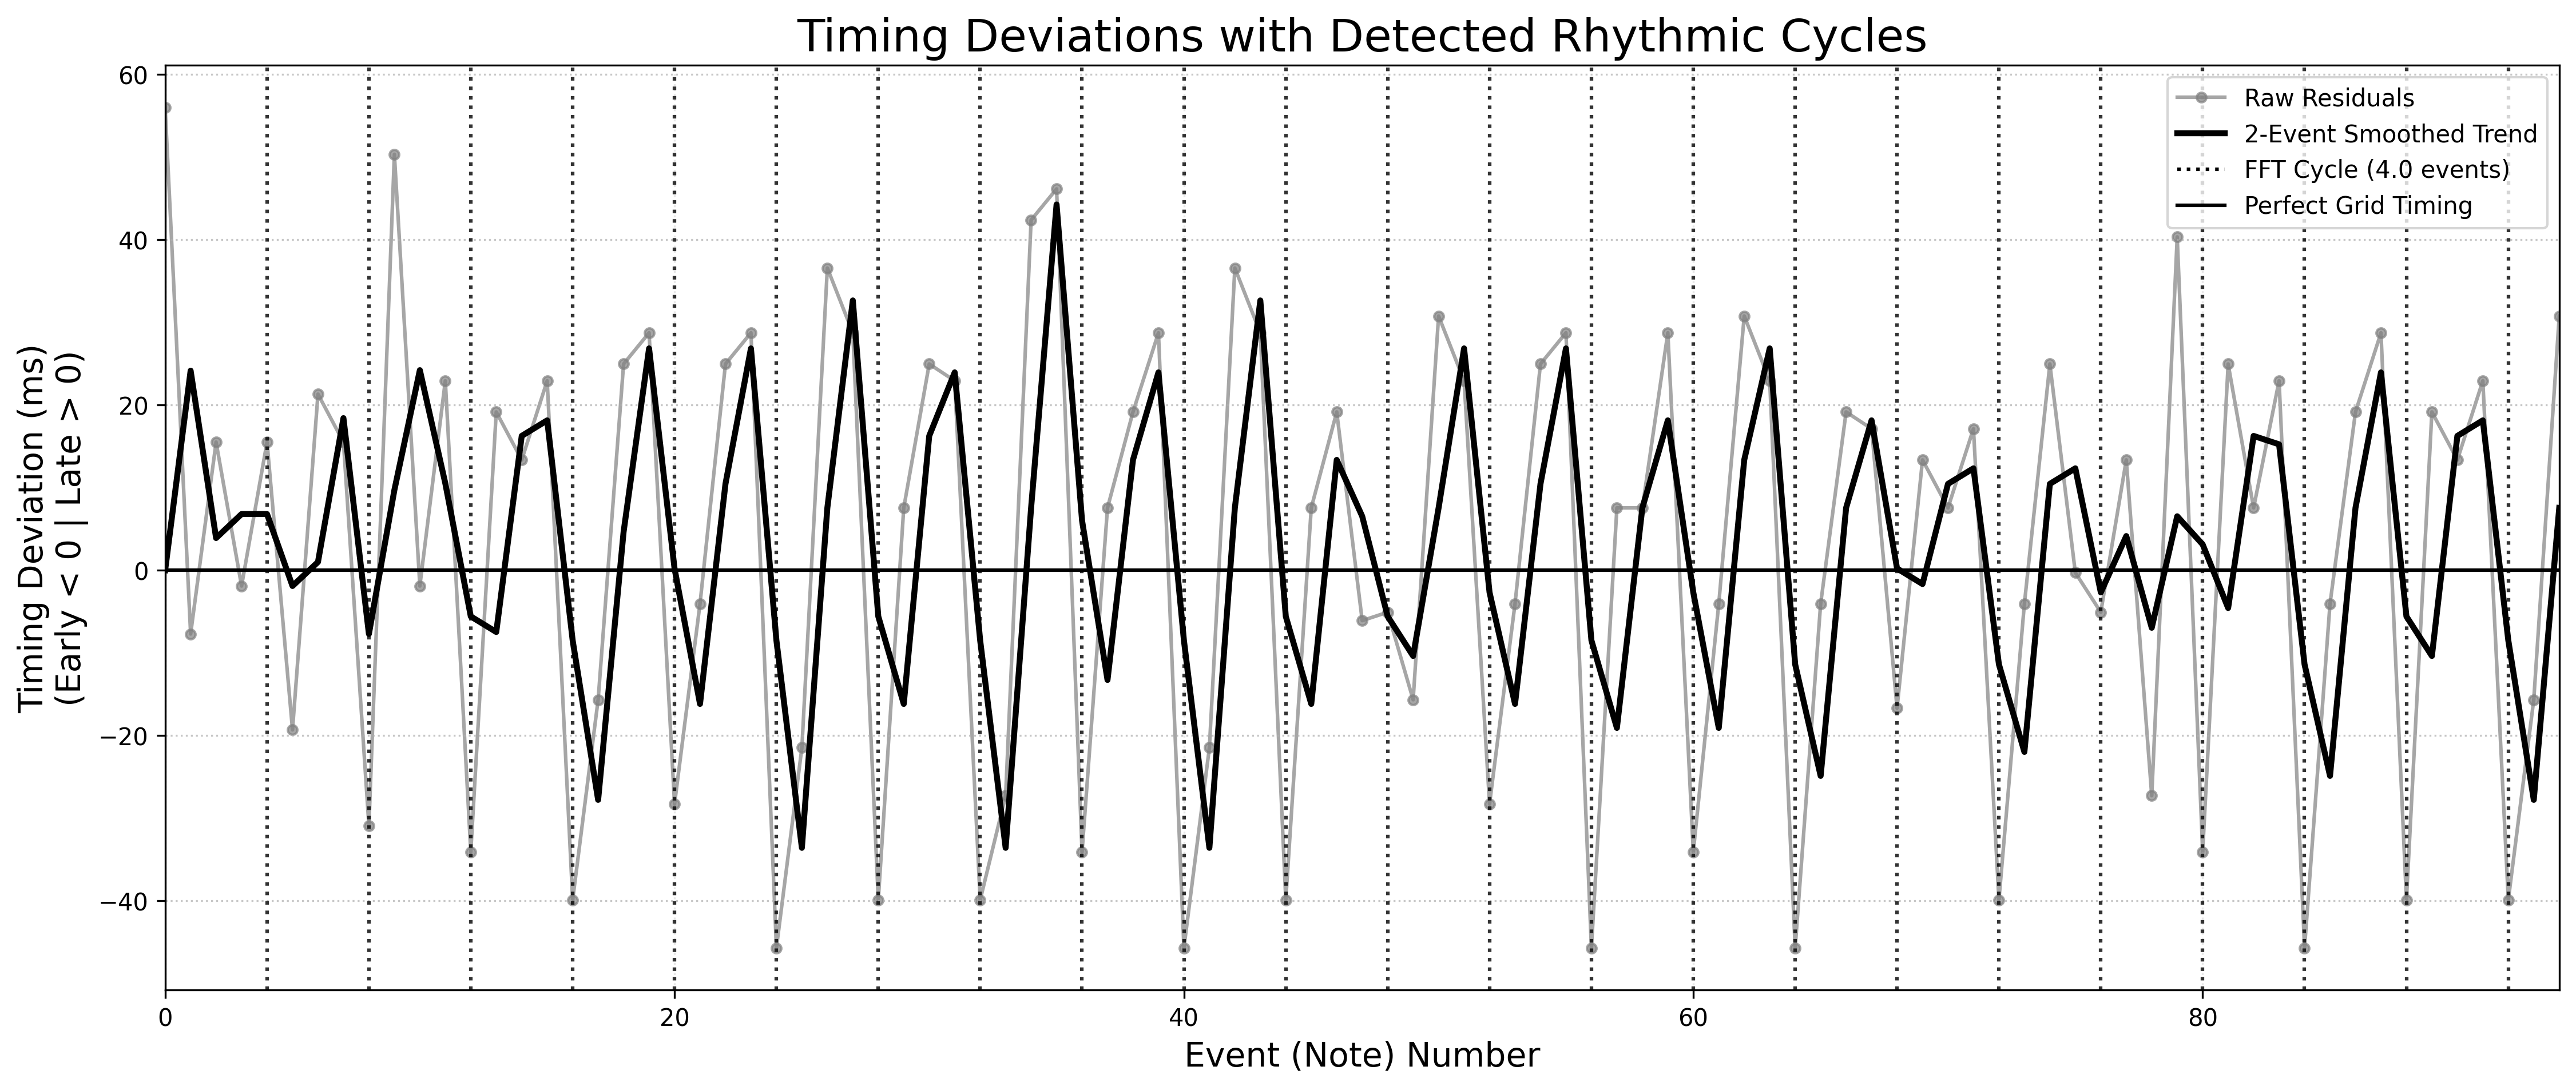


  > INTERPRETATION: Look at the overlays. Which dotted line pattern
    (green '--' or red ':') seems to match the underlying navy trend line better?
    This visual check helps validate which of the detected periods is more musically meaningful.


In [6]:
# ===================================================================
#        CELL 5: ADVANCED RESIDUAL PATTERN ANALYSIS
# This cell performs a deeper analysis of timing deviations.
# 1. It tests multiple smoothing windows to see how patterns emerge.
# 2. It automatically detects patterns using two different methods.
# 3. It visualizes the detected patterns overlaid on the timing data.
# ===================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.fft import rfft, rfftfreq

# --- Configuration ---
# The primary moving average window to use for the main analysis and final plot.
# A good starting point is often 4 or 8.
MAIN_MOVING_AVG_WINDOW = 2

# A list of window sizes to test in the sensitivity analysis.
WINDOW_SIZES_TO_TEST = [2, 3, 4, 8, 12, 16]

# --- Pre-computation Check ---
if 'results_df' not in locals() or results_df.empty:
    print("CRITICAL ERROR: DataFrame 'results_df' not found or is empty.")
    print("Please run the main analysis cell successfully before running this one.")
else:
    residuals_ms = results_df['Residual'].values * 1000
    print(f"Analyzing {len(residuals_ms)} timing residuals...")

    # ===============================================================
    # --- METHOD 1: SENSITIVITY ANALYSIS (Your Second Idea)
    # How does the detected pattern change with the smoothing window?
    # ===============================================================
    print("\n\n" + "="*60)
    print("--- Method 1: Sensitivity Analysis for Smoothing Window ---")
    print("="*60)
    print("Analyzing which patterns are strongest at different levels of smoothing.")
    
    for window in WINDOW_SIZES_TO_TEST:
        # We need at least as many data points as the window size
        if len(residuals_ms) < window:
            continue
            
        smoothed = pd.Series(residuals_ms).rolling(window=window, center=True).mean().fillna(0)
        
        # Perform autocorrelation on the smoothed signal
        autocorr = np.correlate(smoothed - smoothed.mean(), smoothed - smoothed.mean(), mode='full')
        autocorr = autocorr[autocorr.size // 2:] # Keep positive lags
        
        peaks, _ = find_peaks(autocorr, height=np.std(autocorr) * 1.5, distance=2)
        
        if len(peaks) > 0:
            print(f"  - For window size {window:<2}: Strongest pattern repeats every {peaks[0]} events.")
        else:
            print(f"  - For window size {window:<2}: No dominant repeating pattern found.")
            
    print("\n  > INTERPRETATION: Look for a lag number that appears consistently across")
    print("    different window sizes. A consistent result indicates a robust pattern.")


    # ===============================================================
    # --- METHOD 2: AUTOMATED ANALYSIS (Using the Main Window Size)
    # ===============================================================
    print("\n\n" + "="*60)
    print(f"--- Method 2: Detailed Analysis for Window = {MAIN_MOVING_AVG_WINDOW} ---")
    print("="*60)
    
    # Use the smoothed data for the main analysis
    analysis_signal = pd.Series(residuals_ms).rolling(window=MAIN_MOVING_AVG_WINDOW, center=True).mean().fillna(0).values
    
    # --- Part A: Autocorrelation Peak Analysis ---
    primary_lag = None
    autocorr = np.correlate(analysis_signal - analysis_signal.mean(), analysis_signal - analysis_signal.mean(), mode='full')
    autocorr = autocorr[autocorr.size // 2:]
    peaks, _ = find_peaks(autocorr, height=np.std(autocorr), distance=2)
    if len(peaks) > 0:
        primary_lag = peaks[0]
        print(f"[Autocorrelation] Found a repeating motif every {primary_lag} events.")
    else:
        print("[Autocorrelation] No significant repeating motif found.")

    # --- Part B: Fourier Transform (FFT) Analysis ---
    peak_period = None
    N = len(analysis_signal)
    yf = rfft(analysis_signal)
    xf = rfftfreq(N, 1)
    # Find peaks in the frequency spectrum (ignoring the DC offset at index 0)
    if len(xf) > 1:
        fft_peaks, _ = find_peaks(np.abs(yf[1:]), height=np.std(np.abs(yf[1:])), distance=2)
        if len(fft_peaks) > 0:
            strongest_peak_idx = fft_peaks[np.argmax(np.abs(yf[1:][fft_peaks]))] + 1
            peak_freq = xf[strongest_peak_idx]
            if peak_freq > 0:
                peak_period = 1 / peak_freq
                print(f"[FFT]             Found a cyclical wave every {peak_period:.2f} events.")
        else:
            print("[FFT]             No dominant cyclical wave found.")
    else:
        print("[FFT]             Not enough data for FFT analysis.")
        
    # ===============================================================
    # --- METHOD 3: SUMMARY VISUALIZATION (Your First Idea)
    # Plotting the raw data, the smoothed trend, and the detected cycles.
    # ===============================================================
    print("\n\n" + "="*60)
    print("--- Method 3: Summary Visualization with Detected Cycles ---")
    print("="*60)
    
    plt.figure(figsize=(18, 7), dpi=DPI)
    
    # Plot the raw residuals and smoothed average
    plt.plot(residuals_ms, 'o-', color=('gray' if GRAYSCALE else 'silver'), markersize=4, alpha=0.7, label='Raw Residuals', zorder=1)
    plt.plot(analysis_signal, color=('black' if GRAYSCALE else 'navy'), linewidth=2.5, label=f'{MAIN_MOVING_AVG_WINDOW}-Event Smoothed Trend', zorder=2)
    
    # --- Add overlay for FFT result ---
    if peak_period is not None:
        # Round the period to the nearest integer for plotting
        plot_period = round(peak_period)
        for i in np.arange(plot_period, len(residuals_ms), plot_period):
            plt.axvline(x=i, color=('black' if GRAYSCALE else 'red'), linestyle=':', linewidth=1.5, alpha=0.8, zorder=3)
        # Add a single representative line to the legend
        plt.axvline(x=-1, color=('black' if GRAYSCALE else 'red'), linestyle=':', linewidth=1.5, label=f'FFT Cycle ({peak_period:.1f} events)')
        
    plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Perfect Grid Timing', zorder=2)
    plt.title('Timing Deviations with Detected Rhythmic Cycles', fontsize=int(16 * FONT_SCALE))
    plt.xlabel('Event (Note) Number', fontsize=int(12 * FONT_SCALE))
    plt.ylabel('Timing Deviation (ms)\n(Early < 0 | Late > 0)', fontsize=int(12 * FONT_SCALE))
    plt.grid(True, which='major', axis='y', linestyle=':', alpha=0.7)
    plt.grid(True, which='major', axis='x', linestyle=':', alpha=0.3)
    plt.legend()
    plt.xlim(0, len(residuals_ms) -1)
    plt.show()

    print("\n  > INTERPRETATION: Look at the overlays. Which dotted line pattern")
    print("    (green '--' or red ':') seems to match the underlying navy trend line better?")
    print("    This visual check helps validate which of the detected periods is more musically meaningful.")

Analyzing 95 timing residuals...


--- Step 1: Optimizing Smoothing Window via Scoring ---
Scoring complete. The 'Pattern Fit Score' measures how well a repeating
pattern explains the smoothed data (higher is better).

   Window Size  Detected Period  Pattern Fit Score
0            8                2           0.171690
1            6                4           0.083591
2            4                8           0.056047
3            2                4           0.011565

--- OPTIMIZATION COMPLETE ---
The best fit was found with a window size of 8.
It revealed a dominant pattern repeating every 2 events.


--- Step 2: Visualizing Analysis with Optimal Window (8) ---


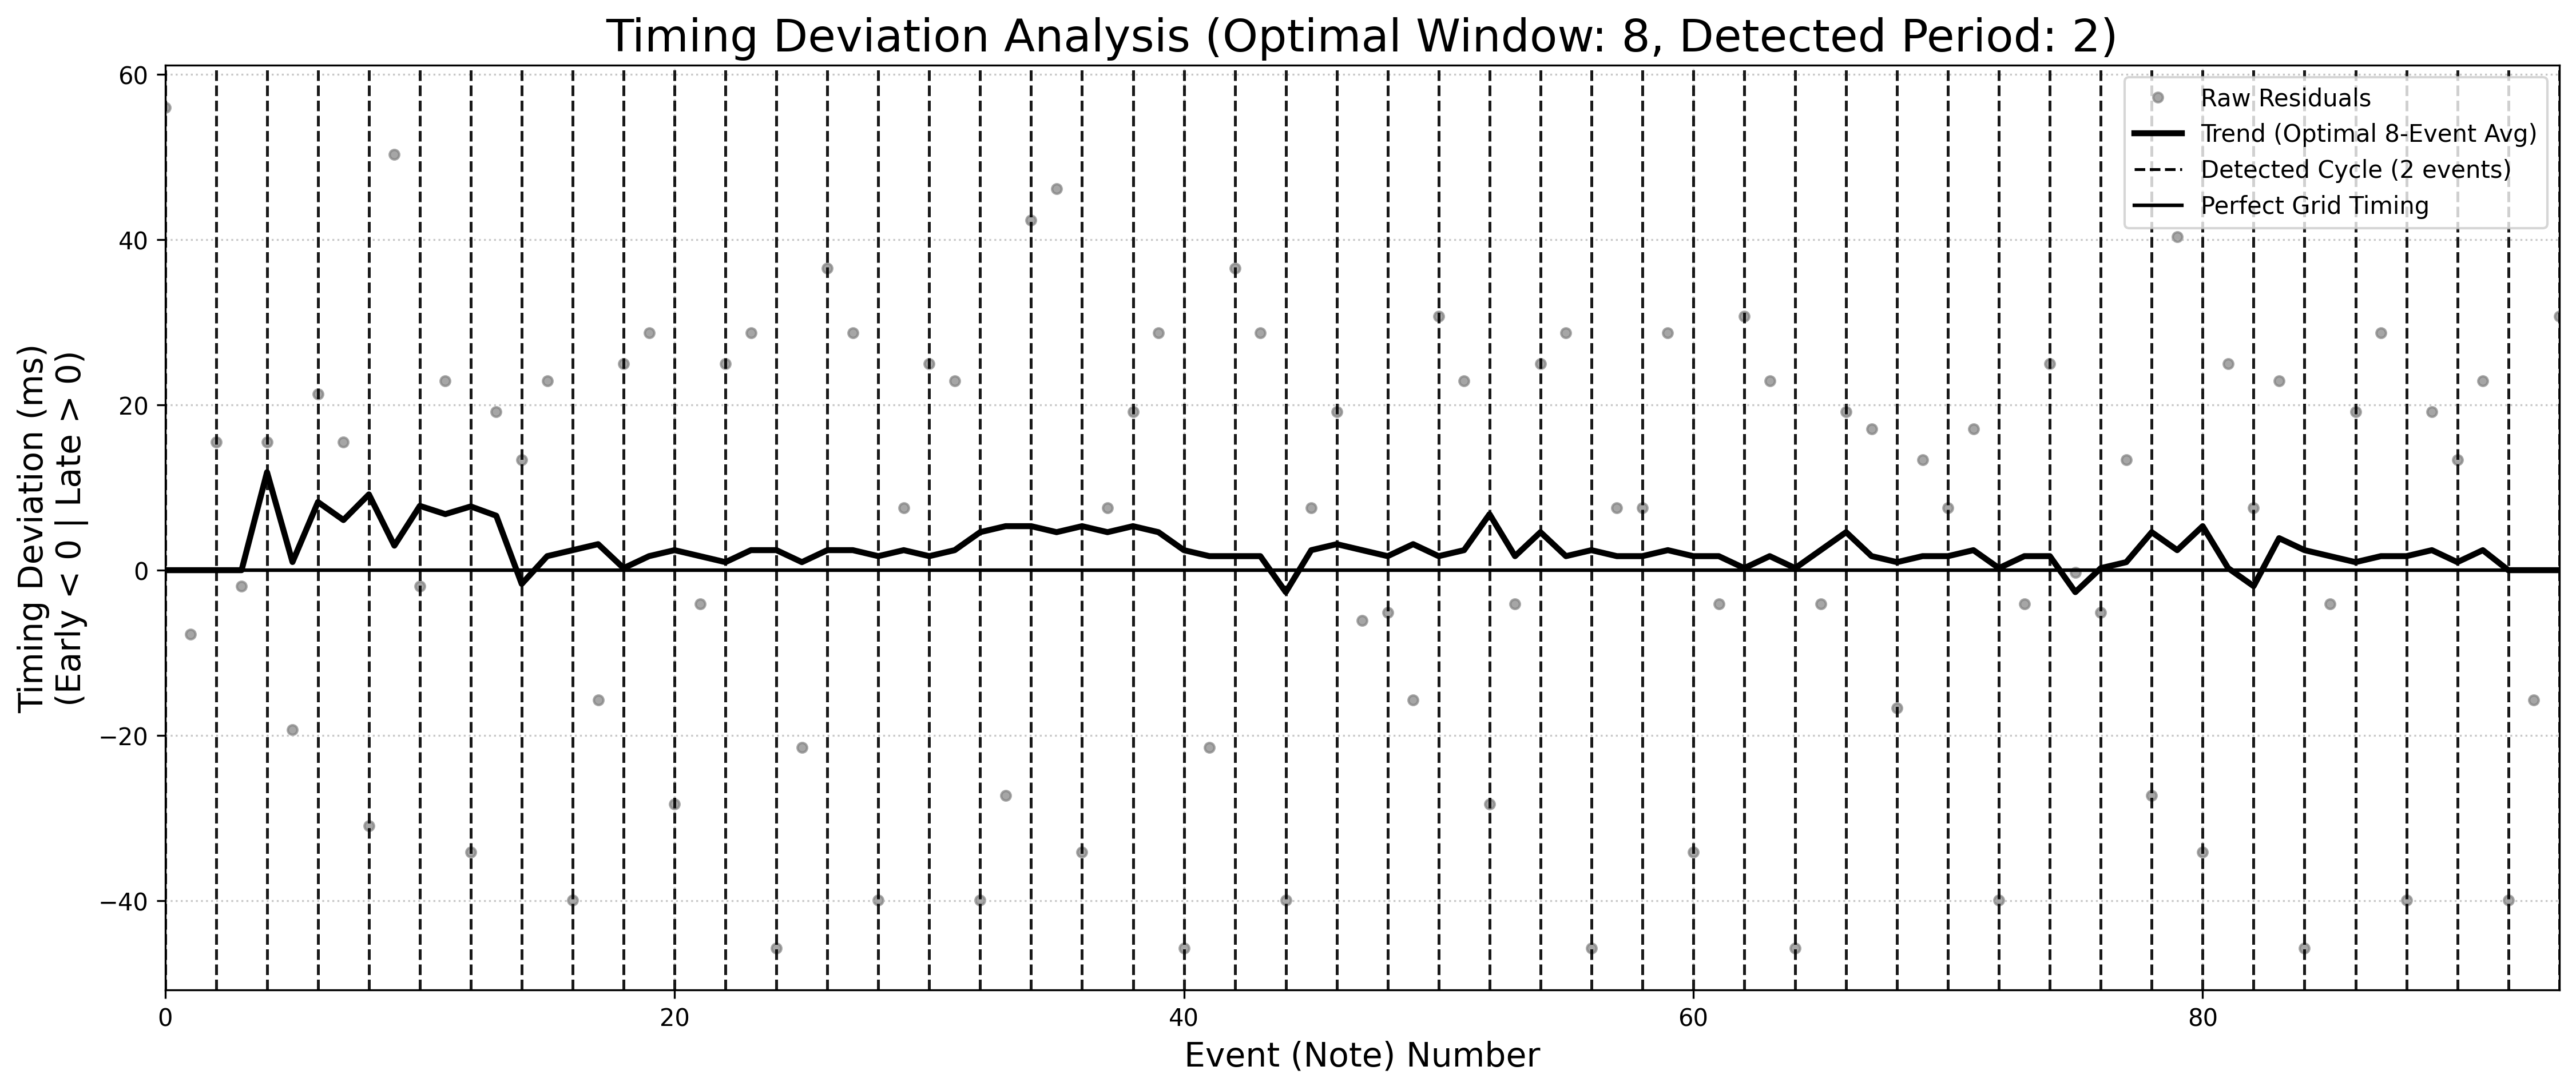

In [7]:
# ===================================================================
#        CELL 6: RESIDUAL PATTERN OPTIMIZER
# This cell automates the search for the best smoothing window
# by calculating a "Pattern Fit Score" for each setting. It then
# uses the winning setting to generate the final analysis plot.
# ===================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.metrics import mean_squared_error

# --- Configuration ---
# A list of window sizes to test in the sensitivity analysis.
# WINDOW_SIZES_TO_TEST = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
WINDOW_SIZES_TO_TEST = [2, 4, 6, 8]

# --- Pre-computation Check ---
if 'results_df' not in locals() or results_df.empty:
    print("CRITICAL ERROR: DataFrame 'results_df' not found or is empty.")
    print("Please run the main analysis cell successfully before running this one.")
else:
    residuals_ms = results_df['Residual'].values * 1000
    print(f"Analyzing {len(residuals_ms)} timing residuals...")

    # ===============================================================
    # --- STEP 1: FIND THE OPTIMAL WINDOW BY SCORING EACH ONE ---
    # ===============================================================
    print("\n\n" + "="*60)
    print("--- Step 1: Optimizing Smoothing Window via Scoring ---")
    print("="*60)
    
    results = []

    for window in WINDOW_SIZES_TO_TEST:
        if len(residuals_ms) < window * 2: # Need enough data for robust analysis
            continue
            
        signal = pd.Series(residuals_ms).rolling(window=window, center=True).mean().fillna(0).values
        
        # Find the most likely repeating period (lag) using autocorrelation
        autocorr = np.correlate(signal - signal.mean(), signal - signal.mean(), mode='full')
        autocorr = autocorr[autocorr.size // 2:]
        peaks, _ = find_peaks(autocorr, height=np.std(autocorr) * 1.5, distance=2)
        
        score = 0
        period = 0
        
        if len(peaks) > 0:
            period = peaks[0]
            if period > 1: # A period of 1 is trivial
                # Create the "ideal" pattern template
                num_cycles = int(np.floor(len(signal) / period))
                trimmed_signal = signal[:num_cycles * period]
                pattern_matrix = trimmed_signal.reshape(num_cycles, period)
                ideal_pattern = pattern_matrix.mean(axis=0)
                
                # Tile the ideal pattern to match the original signal's length
                tiled_pattern = np.tile(ideal_pattern, num_cycles)
                
                # Calculate the Mean Squared Error
                mse = mean_squared_error(trimmed_signal, tiled_pattern)
                
                # The score is the inverse of the error (higher is better). Added a small epsilon to avoid division by zero.
                score = 1 / (mse + 1e-9)

        results.append({'Window Size': window, 'Detected Period': period, 'Pattern Fit Score': score})

    # --- Display the results in a clean table ---
    score_df = pd.DataFrame(results).sort_values(by='Pattern Fit Score', ascending=False).reset_index(drop=True)
    
    print("Scoring complete. The 'Pattern Fit Score' measures how well a repeating")
    print("pattern explains the smoothed data (higher is better).\n")
    print(score_df.to_string())

    # --- Automatically determine the best setting ---
    best_setting = score_df.iloc[0]
    optimal_window = int(best_setting['Window Size'])
    optimal_period = int(best_setting['Detected Period'])

    print(f"\n--- OPTIMIZATION COMPLETE ---")
    if best_setting['Pattern Fit Score'] > 0:
        print(f"The best fit was found with a window size of {optimal_window}.")
        print(f"It revealed a dominant pattern repeating every {optimal_period} events.")
    else:
        print("No consistent, repeating patterns were found with any window size.")
        # Fallback to a default window if no patterns are found
        optimal_window = 4
        optimal_period = 0


    # ===============================================================
    # --- STEP 2: VISUALIZE RESULTS USING THE OPTIMAL WINDOW ---
    # ===============================================================
    print("\n\n" + "="*60)
    print(f"--- Step 2: Visualizing Analysis with Optimal Window ({optimal_window}) ---")
    print("="*60)
    
    final_signal = pd.Series(residuals_ms).rolling(window=optimal_window, center=True).mean().fillna(0).values
    
    plt.figure(figsize=(18, 7), dpi=DPI)
    plt.plot(residuals_ms, 'o', color=('gray' if GRAYSCALE else 'silver'), markersize=4, alpha=0.7, label='Raw Residuals', zorder=1)
    plt.plot(final_signal, color=('black' if GRAYSCALE else 'navy'), linewidth=2.5, label=f'Trend (Optimal {optimal_window}-Event Avg)', zorder=2)
    
    if optimal_period > 0:
        for i in np.arange(0, len(residuals_ms), optimal_period):
            plt.axvline(x=i, color=('black' if GRAYSCALE else 'crimson'), linestyle='--', linewidth=1.2, alpha=0.9, zorder=3)
        plt.axvline(x=-1, color=('black' if GRAYSCALE else 'crimson'), linestyle='--', linewidth=1.2, label=f'Detected Cycle ({optimal_period} events)')
        
    plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Perfect Grid Timing', zorder=2)
    plt.title(f'Timing Deviation Analysis (Optimal Window: {optimal_window}, Detected Period: {optimal_period})', fontsize=int(16 * FONT_SCALE))
    plt.xlabel('Event (Note) Number', fontsize=int(12 * FONT_SCALE))
    plt.ylabel('Timing Deviation (ms)\n(Early < 0 | Late > 0)', fontsize=int(12 * FONT_SCALE))
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.xlim(0, len(residuals_ms) - 1)
    plt.show()